# Project — Football: large-scale data & analytics - Celine BENDEKOUM M1 2SIA

## Objective
The objective of this project is to build a **performance monitoring tool** that can be used by a club (coach, strength & conditioning coach, analyst) from GPS/IMU data.

In practice, we want to be able to answer **quickly, traceably, and consistently** questions such as:
- **What is the load of a match / a training session?** (volume + intensity)
- **How does the load evolve over time?** (trends, spikes, heavy weeks)
- **Which positions / which players are most exposed to high-intensity efforts?**
- **Which sessions are atypical** (too low / too intense / suspicious data)?
- **How do two players compare** with different roles, and **relative to their own habits** (normalization)?

## Operational goal (monitoring tool)
The pipeline must work like a **monitoring system**:
- **Standardize** all sessions (game/practice) into a single database.
- Enable **reusable SQL queries** (same KPIs, same definitions, same filters).
- Produce **readable outputs** for the staff: tables + charts + simple alerts (outliers).
- Ensure a minimum level of **data quality** (impossible values, inconsistencies, NA, etc.) to avoid decisions based on noise.

## Data sources
We use two complementary levels:
- **Raw tracking** (files per sensor, per session): position/speed over time → useful for within-session analysis (phases, peaks, repetitions).
- **summary.csv**: an already aggregated “player–session” summary (distance, speed zones, accelerations/decelerations, max speeds, etc.) → ideal for global monitoring and comparisons.

## Technical deliverable
Build a **DuckDB** database that can be queried in SQL, containing:
- **Ingestion & normalization**: robust import, typing, column harmonization.
- **Quality checks**: simple rules (non-plausible values, zero distances, unrealistic max speeds, consistency between zones and total distance).
- **Reusable SQL views**: “clean” views (ready for analysis), player dimension tables, KPI views (e.g., HID, ratios).

## Analytical deliverable (staff-oriented report)
The report must produce directly actionable analyses:
- **Team overview (match)**: typical match load, variability, profiles by position.
- **Specific session (match)**: one specific date (very intense / very low match), player profiles.
- **Team overview (training)**: training load structure, comparison vs match.
- **Specific session (training)**: a “key” training session (very intense vs light).
- **Team summary**: “dashboard” tables game vs practice, and by position.
- **Comparison of 2 players**: athletic profiles + normalized KPIs (relative to themselves).

## Analysis organization (work plan)
We move from **team-level** to **session-level**, then to **individual**:
1) Matches — team overview  
2) Matches — specific session(s)  
3) Training — team overview  
4) Training — specific session(s)  
5) Team overall summary (dashboard)  
6) Individual comparison of 2 players (profiles + normalization)

## Stack and method (“production” mindset)
- Storage/queries: **DuckDB** (tables + SQL views)
- Manipulation: **pandas / numpy**
- Visualization: **matplotlib / seaborn**
- Principle: **define KPIs and filters once**, reuse them everywhere (consistency), then produce comparisons (match vs training, position, player, period).

-----------------------------------------------------------------------------------------

### Preamble (for the club / staff)

This cell sets up the **reliable working base** that will be used for all subsequent analyses (matches, training sessions, player comparisons).  
The idea is simple: before interpreting KPIs (distance, speeds, sprints, accelerations), we must **centralize**, **standardize**, and **control data quality** to avoid drawing conclusions from outliers or incomplete data.

Concretely, this cell:
1) **Opens the DuckDB database** (`football.duckdb`) so the data can be queried in **SQL** like a “club” database (fast, reproducible).  
   - If the file is locked on Windows (Python kernel already holding it), the code temporarily falls back to an in-memory database (`:memory:`) so you can keep working.

2) **Imports the aggregated `summary.csv` file** into a raw table (`summary_raw`) in a robust mode:  
   - everything is read as text (VARCHAR) and missing values (`NA`, `NaN`, etc.) become `NULL`.  
   Goal: **never block ingestion** because of a missing value or a wrong type.

3) Creates a properly **typed** view `summary` (numeric, dates, etc.) via `try_cast`:  
   - if a value cannot be converted, it becomes `NULL` instead of breaking the pipeline.  
   Goal: a stable schema to compute KPIs and compare sessions/players.

4) Creates a `players` table (player dimension):  
   - associates each sensor with a last/first name to produce staff-readable outputs.

5) Creates a `summary_clean` view = **cleaned data**, ready for monitoring:  
   - applies simple, explainable rules (e.g., negative distance is impossible, unrealistic max speed, a “not used” match player with extremely low distance, consistency between total distance and the sum of speed zones).  
   Goal: produce a “club-ready” base where charts and comparisons reflect real athletic behaviors, not sensor artifacts.

Finally, a small table summarizes how many rows/players remain after cleaning (game vs practice).  
This is the starting point of the tool: **all following analyses use `summary_clean`** to ensure consistency and data quality.

In [28]:
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

DB_PATH = Path("football.duckdb")

con = None  # Initialize first

# Close any previous connection (same kernel)
if "con" in globals() and con is not None:
    try:
        con.close()
    except Exception:
        pass

# DuckDB connection (in-memory fallback if Windows lock)
try:
    con = duckdb.connect(str(DB_PATH))
except Exception as e:
    print("Warning: football.duckdb locked/inaccessible -> falling back to :memory:")
    print(e)
    con = duckdb.connect(database=":memory:")

con.execute("PRAGMA threads=4;")

# 1) Robust raw import (all VARCHAR + NA->NULL)
con.execute("DROP TABLE IF EXISTS summary_raw;")
con.execute("""
CREATE TABLE summary_raw AS
SELECT *
FROM read_csv_auto(
  'data/data/summary.csv',
  header=true,
  all_varchar=true,
  nullstr=['NA','NaN','N/A','']
);
""")

# 2) Typed view (try_cast => never errors)
con.execute("""
CREATE OR REPLACE VIEW summary AS
SELECT
  try_cast("Sensor" AS INTEGER) AS sensor,
  upper("last_name") AS last_name,
  upper("first_name") AS first_name,
  try_cast("date" AS TIMESTAMP) AS session_ts,
  "type" AS session_type,
  "position" AS position,

  try_cast("feature_distance" AS DOUBLE) AS distance_km,
  try_cast("feature_avg_speed" AS DOUBLE) AS avg_speed_kmh,
  try_cast("feature_max_speed" AS DOUBLE) AS max_speed_kmh,
  try_cast("feature_max_acc" AS DOUBLE) AS max_acc_ms2,

  try_cast("feature_d_speed_0_5" AS DOUBLE) AS d_0_5_km,
  try_cast("feature_d_speed_5_10" AS DOUBLE) AS d_5_10_km,
  try_cast("feature_d_speed_10_15" AS DOUBLE) AS d_10_15_km,
  try_cast("feature_d_speed_15_21" AS DOUBLE) AS d_15_21_km,
  try_cast("feature_d_speed_21_24" AS DOUBLE) AS d_21_24_km,
  try_cast("feature_d_speed_24_30" AS DOUBLE) AS d_24_30_km,
  try_cast("feature_d_speed_over30" AS DOUBLE) AS d_over30_km,

  try_cast("feature_acc_3mss" AS DOUBLE) AS acc_3mss,
  try_cast("feature_dec_3mss" AS DOUBLE) AS dec_3mss
FROM summary_raw;
""")

# 3) Player dimension
con.execute("""
CREATE OR REPLACE TABLE players AS
SELECT
  sensor,
  any_value(last_name) AS last_name,
  any_value(first_name) AS first_name
FROM summary
WHERE sensor IS NOT NULL
GROUP BY sensor;
""")

# 4) Cleaning: summary_clean view
# Simple, explainable rules:
# - match: distance >= 0.5 km (otherwise "unused player" / artifact)
# - match: vmax <= 40 km/h (values like 42.5 are suspicious)
# - no negative values
# - consistency: sum of zones <= distance * 1.15 (tolerance)
MIN_MATCH_DISTANCE_KM = 0.5
MAX_MATCH_DISTANCE_KM = 20.0
MAX_MAX_SPEED_KMH = 40.0
ZONE_TOL = 1.15

con.execute(f"""
CREATE OR REPLACE VIEW summary_clean AS
WITH s AS (
  SELECT
    *,
    (coalesce(d_0_5_km,0) + coalesce(d_5_10_km,0) + coalesce(d_10_15_km,0) +
     coalesce(d_15_21_km,0) + coalesce(d_21_24_km,0) + coalesce(d_24_30_km,0) +
     coalesce(d_over30_km,0)) AS zones_sum_km
  FROM summary
)
SELECT *
FROM s
WHERE sensor IS NOT NULL
  AND session_ts IS NOT NULL
  AND session_type IN ('game','practice')

  AND (distance_km IS NULL OR distance_km >= 0)
  AND (max_speed_kmh IS NULL OR max_speed_kmh >= 0)
  AND (acc_3mss IS NULL OR acc_3mss >= 0)
  AND (dec_3mss IS NULL OR dec_3mss >= 0)

  AND (
    distance_km IS NULL
    OR zones_sum_km <= distance_km * {ZONE_TOL}
  )

  AND (
    session_type <> 'game'
    OR (
      distance_km BETWEEN {MIN_MATCH_DISTANCE_KM} AND {MAX_MATCH_DISTANCE_KM}
      AND (max_speed_kmh IS NULL OR max_speed_kmh <= {MAX_MAX_SPEED_KMH})
    )
  );
""")

display(con.sql("""
SELECT session_type, COUNT(*) AS n_rows, COUNT(DISTINCT sensor) AS n_sensors
FROM summary_clean
GROUP BY 1 ORDER BY 1;
""").df())

,session_type,n_rows,n_sensors
0,game,1011,29
1,practice,3030,29


In [29]:
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid")

# ---------------------------
# ANONYMIZATION (ON/OFF)
# ---------------------------
ANONYMIZE_NAMES = True
ANON_PREFIX = "PLAYER"   # e.g. PLAYER_001
ANON_PAD = 3

DB_PATH = Path("football.duckdb")

con = None  # Initialize first

# Close any previous connection (same kernel)
if "con" in globals() and con is not None:
    try:
        con.close()
    except Exception:
        pass

# DuckDB connection (in-memory fallback if Windows lock)
try:
    con = duckdb.connect(str(DB_PATH))
except Exception as e:
    print("Warning: football.duckdb locked/inaccessible -> falling back to :memory:")
    print(e)
    con = duckdb.connect(database=":memory:")

con.execute("PRAGMA threads=4;")

# 1) Robust raw import (all VARCHAR + NA->NULL)
con.execute("DROP TABLE IF EXISTS summary_raw;")
con.execute("""
CREATE TABLE summary_raw AS
SELECT *
FROM read_csv_auto(
  'data/data/summary.csv',
  header=true,
  all_varchar=true,
  nullstr=['NA','NaN','N/A','']
);
""")

# 2) Typed view (try_cast => never errors)
#    + if anonymization enabled: neutralize last/first name columns in the "summary" view
LAST_NAME_EXPR = "NULL::VARCHAR" if ANONYMIZE_NAMES else 'upper("last_name")'
FIRST_NAME_EXPR = "NULL::VARCHAR" if ANONYMIZE_NAMES else 'upper("first_name")'

con.execute(f"""
CREATE OR REPLACE VIEW summary AS
SELECT
  try_cast("Sensor" AS INTEGER) AS sensor,
  {LAST_NAME_EXPR} AS last_name,
  {FIRST_NAME_EXPR} AS first_name,
  try_cast("date" AS TIMESTAMP) AS session_ts,
  "type" AS session_type,
  "position" AS position,

  try_cast("feature_distance" AS DOUBLE) AS distance_km,
  try_cast("feature_avg_speed" AS DOUBLE) AS avg_speed_kmh,
  try_cast("feature_max_speed" AS DOUBLE) AS max_speed_kmh,
  try_cast("feature_max_acc" AS DOUBLE) AS max_acc_ms2,

  try_cast("feature_d_speed_0_5" AS DOUBLE) AS d_0_5_km,
  try_cast("feature_d_speed_5_10" AS DOUBLE) AS d_5_10_km,
  try_cast("feature_d_speed_10_15" AS DOUBLE) AS d_10_15_km,
  try_cast("feature_d_speed_15_21" AS DOUBLE) AS d_15_21_km,
  try_cast("feature_d_speed_21_24" AS DOUBLE) AS d_21_24_km,
  try_cast("feature_d_speed_24_30" AS DOUBLE) AS d_24_30_km,
  try_cast("feature_d_speed_over30" AS DOUBLE) AS d_over30_km,

  try_cast("feature_acc_3mss" AS DOUBLE) AS acc_3mss,
  try_cast("feature_dec_3mss" AS DOUBLE) AS dec_3mss
FROM summary_raw;
""")

# 3) Player dimension (table players)
#    - if anonymization: deterministic mapping sensor -> PLAYER_###
#    - else: real last/first names
if ANONYMIZE_NAMES:
    con.execute(f"""
    CREATE OR REPLACE TABLE players AS
    WITH sensors AS (
      SELECT DISTINCT sensor
      FROM summary
      WHERE sensor IS NOT NULL
    )
    SELECT
      sensor,
      '{ANON_PREFIX}_' || lpad(cast(dense_rank() OVER (ORDER BY sensor) AS VARCHAR), {ANON_PAD}, '0') AS last_name,
      ''::VARCHAR AS first_name
    FROM sensors
    ORDER BY sensor;
    """)
else:
    con.execute("""
    CREATE OR REPLACE TABLE players AS
    SELECT
      sensor,
      any_value(last_name) AS last_name,
      any_value(first_name) AS first_name
    FROM summary
    WHERE sensor IS NOT NULL
    GROUP BY sensor;
    """)

# 4) Cleaning: summary_clean view
# Simple, explainable rules:
# - match: distance >= 0.5 km (otherwise "unused player" / artifact)
# - match: vmax <= 40 km/h (values like 42.5 are suspicious)
# - no negative values
# - consistency: sum of zones <= distance * 1.15 (tolerance)
MIN_MATCH_DISTANCE_KM = 0.5
MAX_MATCH_DISTANCE_KM = 20.0
MAX_MAX_SPEED_KMH = 40.0
ZONE_TOL = 1.15

con.execute(f"""
CREATE OR REPLACE VIEW summary_clean AS
WITH s AS (
  SELECT
    *,
    (coalesce(d_0_5_km,0) + coalesce(d_5_10_km,0) + coalesce(d_10_15_km,0) +
     coalesce(d_15_21_km,0) + coalesce(d_21_24_km,0) + coalesce(d_24_30_km,0) +
     coalesce(d_over30_km,0)) AS zones_sum_km
  FROM summary
)
SELECT *
FROM s
WHERE sensor IS NOT NULL
  AND session_ts IS NOT NULL
  AND session_type IN ('game','practice')

  AND (distance_km IS NULL OR distance_km >= 0)
  AND (max_speed_kmh IS NULL OR max_speed_kmh >= 0)
  AND (acc_3mss IS NULL OR acc_3mss >= 0)
  AND (dec_3mss IS NULL OR dec_3mss >= 0)

  AND (
    distance_km IS NULL
    OR zones_sum_km <= distance_km * {ZONE_TOL}
  )

  AND (
    session_type <> 'game'
    OR (
      distance_km BETWEEN {MIN_MATCH_DISTANCE_KM} AND {MAX_MATCH_DISTANCE_KM}
      AND (max_speed_kmh IS NULL OR max_speed_kmh <= {MAX_MAX_SPEED_KMH})
    )
  );
""")

display(con.sql("""
SELECT session_type, COUNT(*) AS n_rows, COUNT(DISTINCT sensor) AS n_sensors
FROM summary_clean
GROUP BY 1 ORDER BY 1;
""").df())

,session_type,n_rows,n_sensors
0,game,1011,29
1,practice,3030,29


## 1) Matches — team overview (game global)

### Objective

### Why this section exists (on-field use)
This section corresponds to the “**matchday monitoring**” building block in a club: it helps **quantify the real external load imposed by match days** and make it comparable over time and between players/positions.

The goal is not to “look nice”, but to produce actionable indicators for the staff, for example:
- **Planning**: spot very heavy matches → adapt MD+1 / MD+2 sessions.
- **Injury prevention / load management**: identify highly exposed profiles (high HID, many accelerations/decelerations).
- **Understanding match style**: “slow” match vs “very intense” match (speed zones + HID ratio).
- **Load equity**: who really played / who was barely used (very low distances).
- **Benchmarking**: define what a “typical match” is for the team (median/IQR) and detect anomalies.

> Important: we work on `summary_clean` (quality-controlled data) to avoid interpreting impossible values (e.g., unrealistic max speed, inconsistent distances).

---

## What the code does (staff translation)

### 1) Building a “player–match” dataset (table `games_players`)
The SQL extracts one row per **player × match date** with:
- **Total volume**: `distance_km`
- **Intensity**:
  - `max_speed_kmh` (player’s max speed)
  - `acc_3mss`, `dec_3mss` (number of accelerations/decelerations ≥ 3 m/s²)
- **Distance split by speed zones** (0–5, 5–10, …, >30 km/h)

This “player–match” format is the standard monitoring base: we can then aggregate to team level, compare positions, and analyze distributions.

### 2) HID (High-Intensity Distance) and HID ratio
The code computes:
- **HID (km)** = high-intensity distance, here **from 21 km/h**  
  `hid_km = d_21_24 + d_24_30 + d_over30`
- **HID ratio** = share of intensity within the total load  
  `hid_ratio = hid_km / distance_km`

Staff interpretation:
- Two players can have the same total distance but a **different HID ratio** → one experienced a more “explosive / high-intensity” match.

### 3) “Team by match” aggregation (table `team_by_match`)
We then aggregate **all players** from a match to get a team summary per date:
- `n_players`: how many players have data that day
- `team_distance_km`: sum of distances (team volume)
- `team_hid_km` and `team_hid_ratio`: team intensity
- `team_acc_3mss`, `team_dec_3mss`: mechanical load (speed changes)
- `avg_player_max_speed_kmh` vs `max_player_max_speed_kmh`:
  - average of players’ max speeds (overall level)
  - best max speed of the match (individual peak)

---

## How to read the outputs (what each chart adds)

### A) Time series (4 charts)
Goal: visualize **match-to-match variability**.
- **Team total distance**: overall volume (“long/active” vs “low” match)
- **Team HID share**: relative intensity (very intense match even if total distance is average)
- **Team acc/dec**: “mechanical load” (many transitions, pressing, duels)
- **Max speed**:
  - if the match max is very high but the average stays normal → 1–2 players sprinted hard
  - if both rise → globally fast match

Practical use: identify spikes → adjust recovery / training.

### B) Stacked bars by speed zones
Goal: understand *where* the distance is done.
- More 0–15 km/h = more “controlled” match (positioning, circulation)
- More 21+ km/h = more “high intensity” match (runs, transitions)

The code aggregates by month if there are many matches: useful to see period trends (start/end of season).

### C) Global distribution (median, IQR, top/bottom)
Goal: define a **typical match** and the spread.
- **Median**: “typical” value (more robust than mean with outliers)
- **IQR** (Q3–Q1): “normal” variability  
  → the larger the IQR, the more heterogeneous the match loads.

Top/bottom players:
- **Top distance/HID**: most demanded players in matches (often midfielders/wingers depending on style)
- **Bottom distance**: may reflect substitutes, reduced playing time, or a specific role  
  (interpret with caution: ideally with minutes played, not available here)

### D) Boxplots by position
Goal: objectify **structural role differences**.
- Distance by position: typical volume
- HID ratio by position: relative intensity of the role
- Max speed by position: sprint exposure
- Acc/Dec by position: mechanical load

Staff use: build position benchmarks and spot an “out-of-profile” player (return from injury, role change, fatigue).

---

## Expected outcome (monitoring tool)
At the end of this section, the club has:
- a “match load” curve (volume + intensity + mechanical),
- a description of match style via speed zones,
- player/position benchmarks (median/IQR),
- useful top/bottom lists for the staff.

This is the base to compare training vs match (sections 3–5) and to normalize individual profiles (section 6).

,session_date,n_players,team_distance_km,team_hid_km,team_acc_3mss,team_dec_3mss,avg_player_max_speed_kmh,max_player_max_speed_kmh,team_d_0_5_km,team_d_5_10_km,team_d_10_15_km,team_d_15_21_km,team_d_21_24_km,team_d_24_30_km,team_d_over30_km,team_hid_ratio
0,2019-07-09,18,112.54,4.41,770.0,973.0,28.236111,31.42,21.09,39.24,32.41,15.32,2.63,1.77,0.01,0.039186
1,2019-07-12,12,106.18,3.69,723.0,925.0,28.765833,32.45,23.55,36.86,29.10,12.98,2.16,1.45,0.08,0.034752
2,2019-07-20,13,102.01,3.39,693.0,817.0,29.000769,33.44,28.49,35.75,24.14,10.24,1.99,1.32,0.08,0.033232
3,2019-07-25,11,103.66,2.64,629.0,757.0,28.117273,30.46,25.50,40.67,24.45,10.39,1.60,1.02,0.02,0.025468
4,2019-07-28,16,122.23,4.41,791.0,852.0,25.213750,32.03,37.31,38.40,28.61,13.51,2.71,1.64,0.06,0.036080
5,2019-08-01,13,107.16,3.23,969.0,917.0,28.263077,33.09,23.61,39.09,28.81,12.38,1.94,1.26,0.03,0.030142
6,2019-08-04,13,109.35,2.96,589.0,840.0,28.306923,31.20,27.85,40.73,26.07,11.75,1.85,1.08,0.03,0.027069
7,2019-08-08,13,109.17,3.05,734.0,958.0,28.199231,30.04,24.39,40.13,29.73,11.91,1.80,1.25,0.00,0.027938
8,2019-08-11,13,108.30,3.94,726.0,775.0,29.700000,34.78,25.44,38.95,28.35,11.64,2.16,1.59,0.19,0.036380
9,2019-08-15,13,107.74,2.44,615.0,787.0,27.429231,30.92,30.67,40.22,25.51,8.89,1.59,0.83,0.02,0.022647


Number of matches (clean): 73


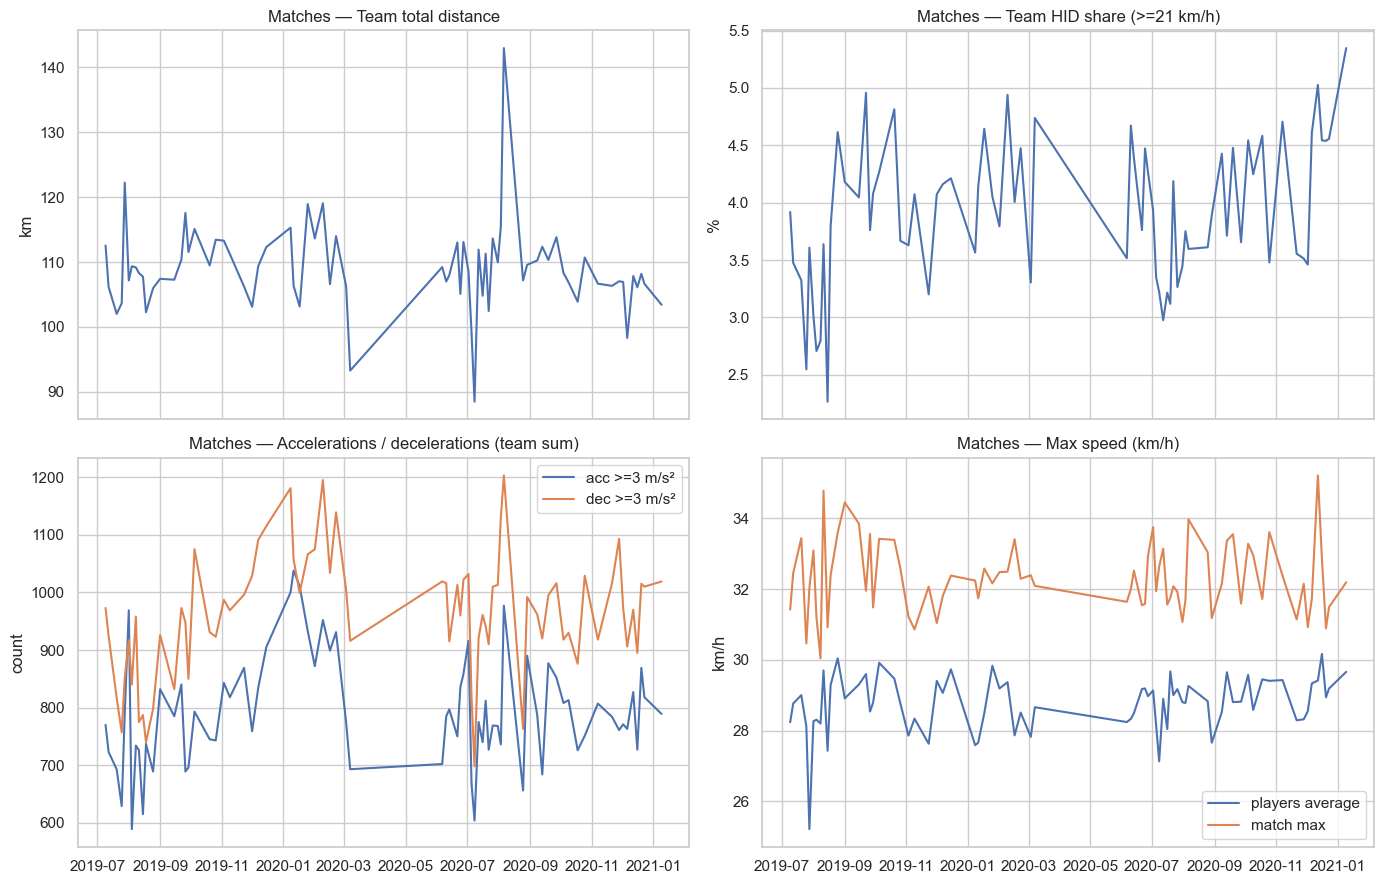

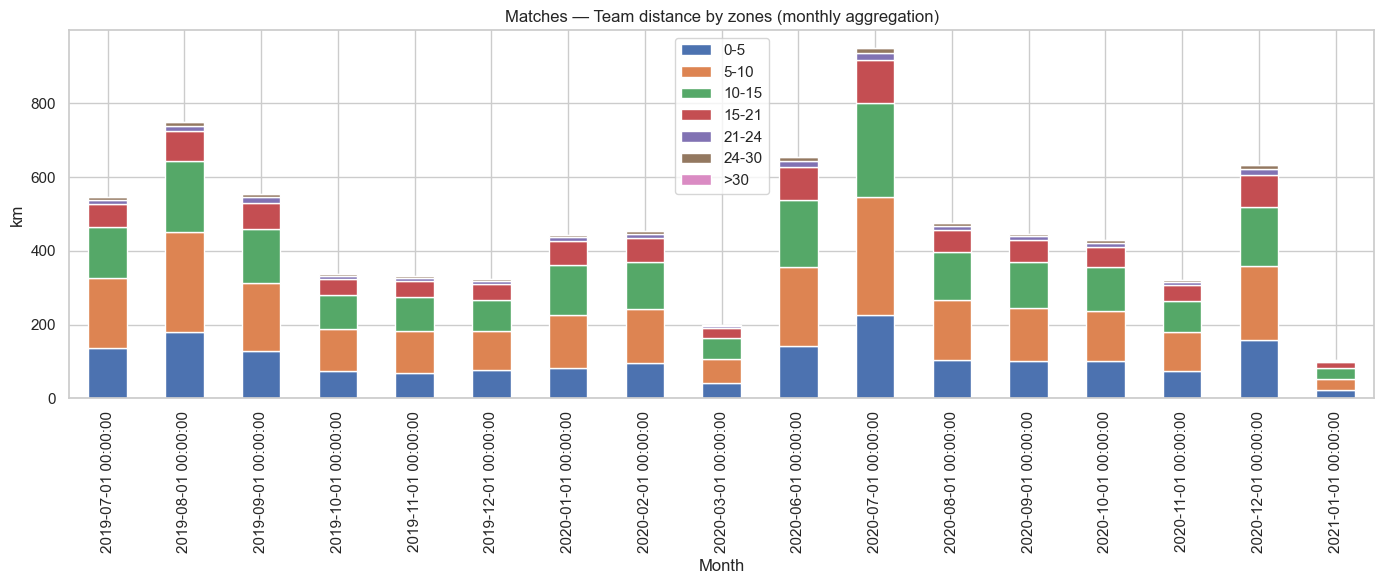

,n,median_distance_km,iqr_distance_km,median_hid_ratio,iqr_hid_ratio,median_max_speed,iqr_max_speed,median_acc,iqr_acc,median_dec,iqr_dec
distance_km,1011.0,8.91,5.675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hid_ratio,NaN,NaN,NaN,0.038113,0.02569,NaN,NaN,NaN,NaN,NaN,NaN
max_speed_kmh,NaN,NaN,NaN,NaN,NaN,28.78,2.835,NaN,NaN,NaN,NaN
acc_3mss,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.0,41.0,NaN,NaN
dec_3mss,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.0,51.0


Top 10 players (average distance per match):


,sensor,last_name,first_name,position,n_games,avg_distance_km,avg_hid_km,avg_max_speed_kmh
22,14,PLAYER_015,,center midfield,51,10.374510,0.234902,27.068039
41,25,PLAYER_026,,artin left,11,9.900000,0.527273,29.458182
6,4,PLAYER_005,,center back,63,9.871111,0.272063,27.899206
17,10,PLAYER_011,,center midfield,15,9.740667,0.425333,28.974667
24,15,PLAYER_016,,center midfield,57,9.626667,0.344211,28.590175
45,77,PLAYER_029,,ilip center,19,9.325789,0.412105,29.321579
7,5,PLAYER_006,,center back,64,9.058281,0.232813,29.061094
20,12,PLAYER_013,,left back,65,8.976154,0.348308,29.389538
23,14,PLAYER_015,,lex center,7,8.844286,0.200000,27.244286
26,17,PLAYER_018,,left forward,2,8.835000,0.555000,29.110000


Bottom 10 players (average distance per match):


,sensor,last_name,first_name,position,n_games,avg_distance_km,avg_hid_km,avg_max_speed_kmh
29,19,PLAYER_020,,left forward,5,1.968000,0.112000,26.926000
19,11,PLAYER_012,,right back,1,2.900000,0.110000,27.090000
43,28,PLAYER_028,,center forward,24,3.239167,0.177917,27.562083
33,20,PLAYER_021,,left forward,13,3.278462,0.191538,30.040769
0,0,PLAYER_001,,left back,6,3.321667,0.166667,30.168333
32,20,PLAYER_021,,center midfield,4,3.362500,0.137500,26.830000
10,6,PLAYER_007,,left back,7,3.472857,0.192857,28.294286
36,21,PLAYER_022,,right midfield,8,3.883750,0.197500,29.328750
31,20,PLAYER_021,,center forward,27,4.463704,0.186296,28.382593
8,6,PLAYER_007,,center forward,2,4.475000,0.250000,28.785000


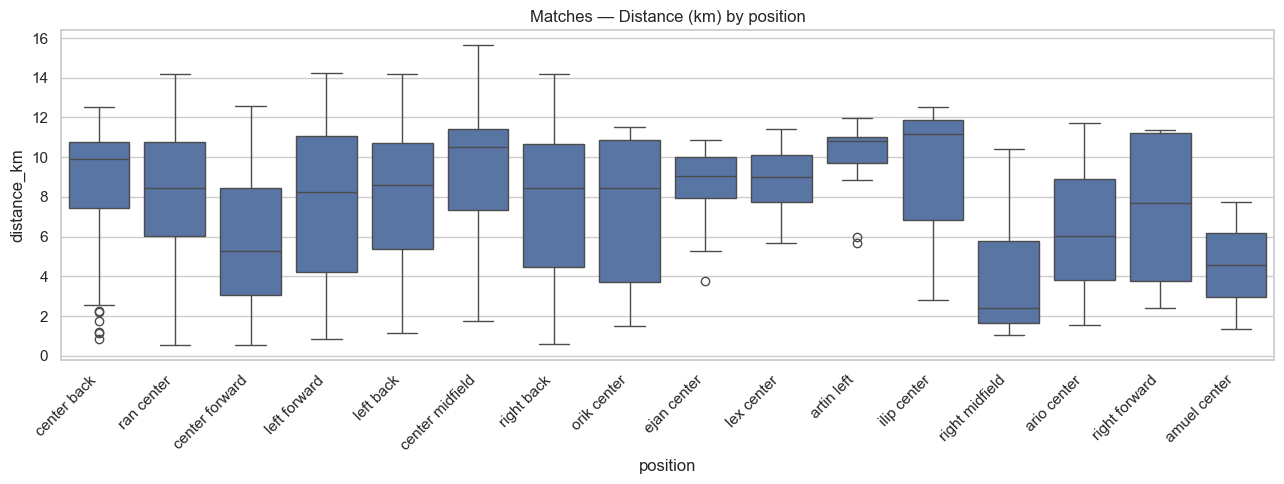

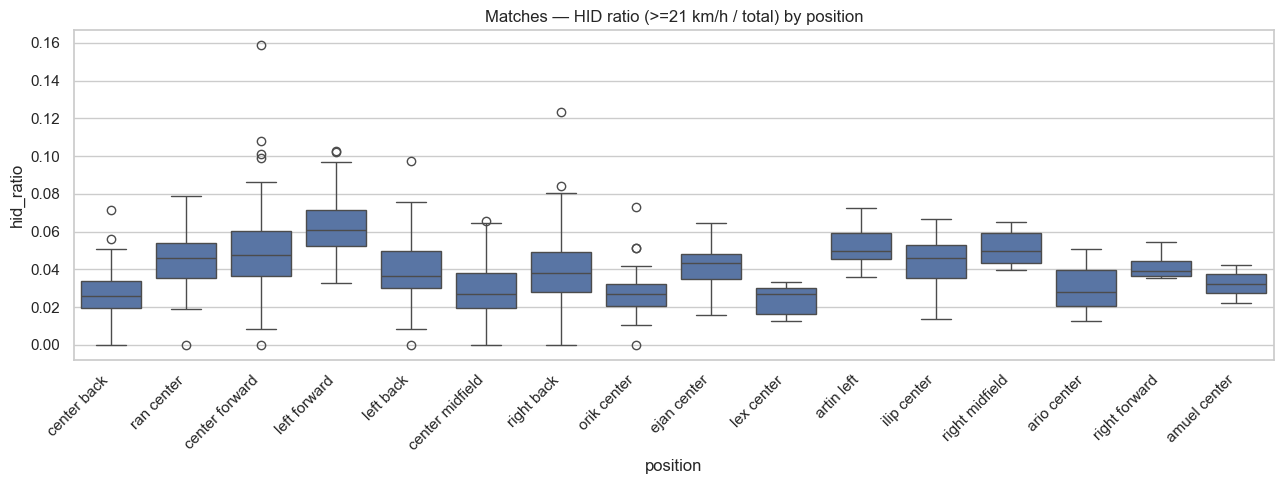

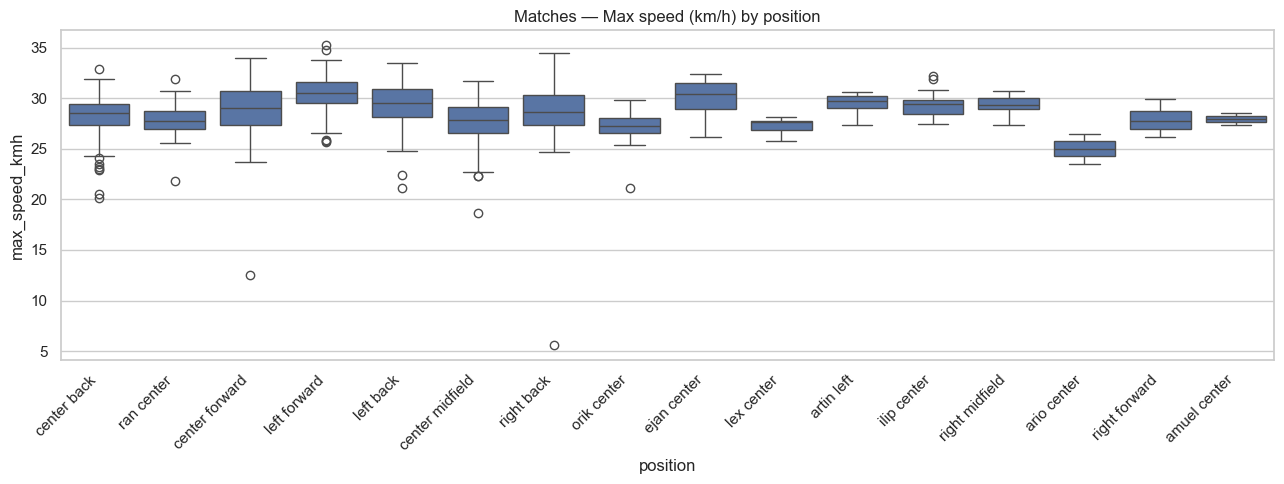

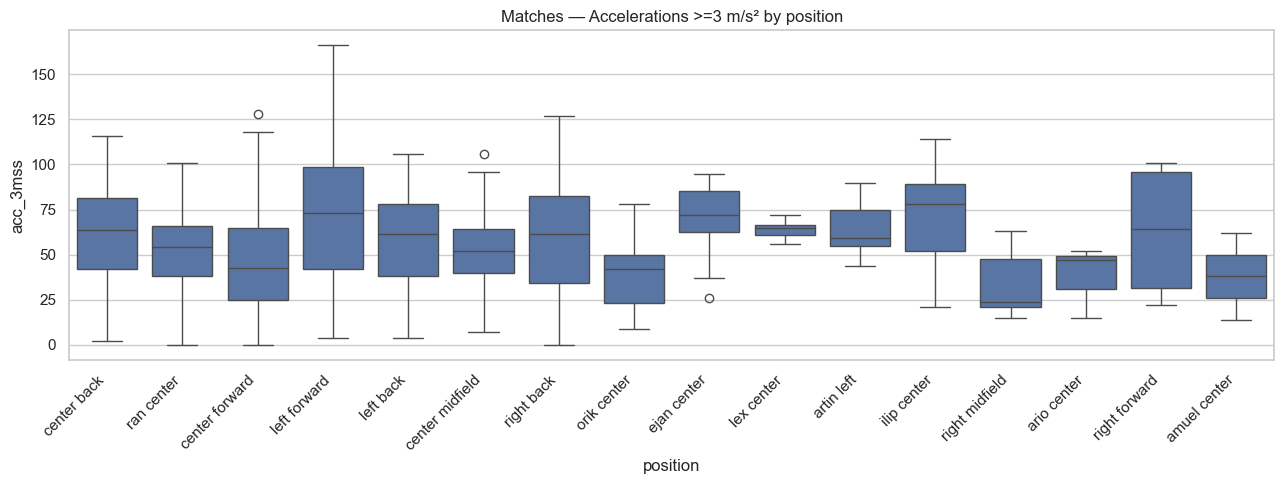

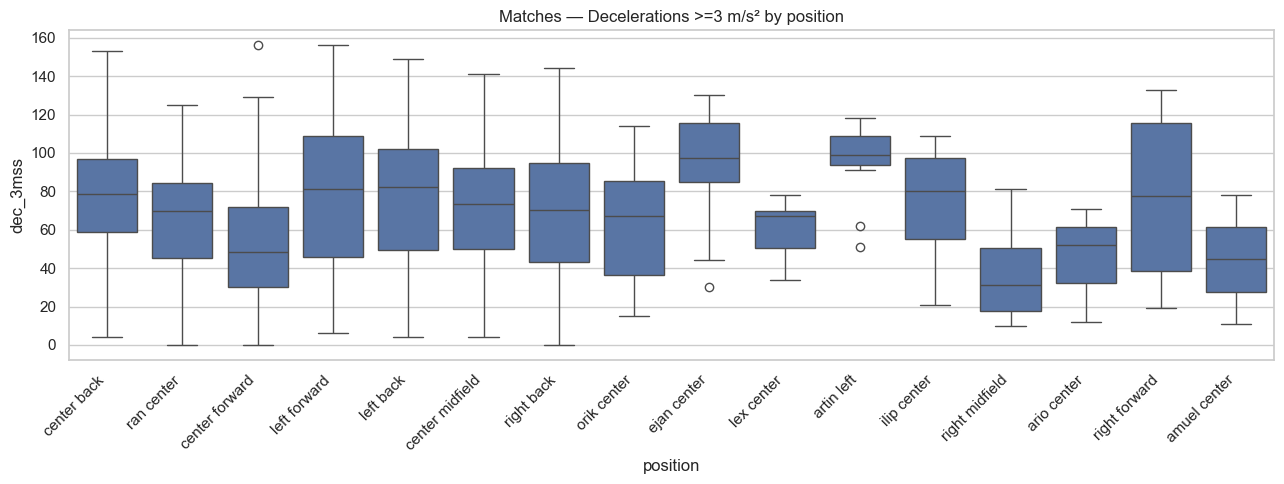

,position,n,median_distance_km,iqr_distance_km,median_hid_ratio,iqr_hid_ratio,median_max_speed,iqr_max_speed
0,ilip center,19,11.160,5.0050,0.046256,0.017430,29.450,1.3500
1,artin left,11,10.830,1.3450,0.049861,0.013620,29.670,1.1950
2,center midfield,168,10.520,4.0750,0.027102,0.018313,27.880,2.5375
3,center back,172,9.905,3.3550,0.026146,0.014123,28.485,2.0950
4,ejan center,14,9.075,2.0575,0.043301,0.013133,30.440,2.5675
5,lex center,7,9.000,2.3800,0.027098,0.013599,27.630,0.9450
6,left back,102,8.620,5.3325,0.036410,0.019627,29.530,2.7700
7,right back,122,8.475,6.1975,0.038079,0.021559,28.655,2.8875
8,ran center,52,8.470,4.7600,0.046127,0.018476,27.725,1.8375
9,orik center,27,8.440,7.1600,0.026882,0.011723,27.260,1.4500


In [30]:
from IPython.display import display

# ---------------------------
# 1) MATCHES — TEAM OVERVIEW
# ---------------------------

# Cleaned player–match dataset
games_players = con.sql("""
SELECT
  date_trunc('day', session_ts)::DATE AS session_date,
  sensor,
  position,
  distance_km,
  max_speed_kmh,
  coalesce(acc_3mss, 0) AS acc_3mss,
  coalesce(dec_3mss, 0) AS dec_3mss,

  coalesce(d_0_5_km, 0) AS d_0_5_km,
  coalesce(d_5_10_km, 0) AS d_5_10_km,
  coalesce(d_10_15_km, 0) AS d_10_15_km,
  coalesce(d_15_21_km, 0) AS d_15_21_km,
  coalesce(d_21_24_km, 0) AS d_21_24_km,
  coalesce(d_24_30_km, 0) AS d_24_30_km,
  coalesce(d_over30_km, 0) AS d_over30_km
FROM summary_clean
WHERE session_type='game';
""").df()

# HID (>=21 km/h)
games_players["hid_km"] = (
    games_players["d_21_24_km"] + games_players["d_24_30_km"] + games_players["d_over30_km"]
)
games_players["hid_ratio"] = np.where(
    (games_players["distance_km"].notna()) & (games_players["distance_km"] > 0),
    games_players["hid_km"] / games_players["distance_km"],
    np.nan
)

# Team aggregation by match
team_by_match = (
    games_players
    .groupby("session_date", as_index=False)
    .agg(
        n_players=("sensor", "nunique"),
        team_distance_km=("distance_km", "sum"),
        team_hid_km=("hid_km", "sum"),
        team_acc_3mss=("acc_3mss", "sum"),
        team_dec_3mss=("dec_3mss", "sum"),
        avg_player_max_speed_kmh=("max_speed_kmh", "mean"),
        max_player_max_speed_kmh=("max_speed_kmh", "max"),

        team_d_0_5_km=("d_0_5_km", "sum"),
        team_d_5_10_km=("d_5_10_km", "sum"),
        team_d_10_15_km=("d_10_15_km", "sum"),
        team_d_15_21_km=("d_15_21_km", "sum"),
        team_d_21_24_km=("d_21_24_km", "sum"),
        team_d_24_30_km=("d_24_30_km", "sum"),
        team_d_over30_km=("d_over30_km", "sum"),
    )
    .sort_values("session_date")
)

team_by_match["team_hid_ratio"] = team_by_match["team_hid_km"] / team_by_match["team_distance_km"].replace({0: np.nan})
team_by_match["session_date"] = pd.to_datetime(team_by_match["session_date"])

display(team_by_match.head(10))
print("Number of matches (clean):", team_by_match["session_date"].nunique())

# ---------------------------
# A) TEAM LOAD: time series
# ---------------------------
fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

ax[0, 0].plot(team_by_match["session_date"], team_by_match["team_distance_km"])
ax[0, 0].set_title("Matches — Team total distance")
ax[0, 0].set_ylabel("km")

ax[0, 1].plot(team_by_match["session_date"], 100 * team_by_match["team_hid_ratio"])
ax[0, 1].set_title("Matches — Team HID share (>=21 km/h)")
ax[0, 1].set_ylabel("%")

ax[1, 0].plot(team_by_match["session_date"], team_by_match["team_acc_3mss"], label="acc >=3 m/s²")
ax[1, 0].plot(team_by_match["session_date"], team_by_match["team_dec_3mss"], label="dec >=3 m/s²")
ax[1, 0].set_title("Matches — Accelerations / decelerations (team sum)")
ax[1, 0].set_ylabel("count")
ax[1, 0].legend()

ax[1, 1].plot(team_by_match["session_date"], team_by_match["avg_player_max_speed_kmh"], label="players average")
ax[1, 1].plot(team_by_match["session_date"], team_by_match["max_player_max_speed_kmh"], label="match max")
ax[1, 1].set_title("Matches — Max speed (km/h)")
ax[1, 1].set_ylabel("km/h")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

# ---------------------------
# B) Team distance by speed zones
# (monthly aggregation if many matches)
# ---------------------------
zones_cols = [
    "team_d_0_5_km", "team_d_5_10_km", "team_d_10_15_km",
    "team_d_15_21_km", "team_d_21_24_km", "team_d_24_30_km", "team_d_over30_km"
]
zones_labels = ["0-5", "5-10", "10-15", "15-21", "21-24", "24-30", ">30"]

zones = team_by_match[["session_date"] + zones_cols].copy()
zones = zones.rename(columns=dict(zip(zones_cols, zones_labels)))

if len(zones) > 25:
    zones["month"] = zones["session_date"].dt.to_period("M").dt.to_timestamp()
    zones_plot = zones.groupby("month")[zones_labels].sum()
    xlab = "Month"
    title = "Matches — Team distance by zones (monthly aggregation)"
else:
    zones_plot = zones.set_index("session_date")[zones_labels]
    xlab = "Match"
    title = "Matches — Team distance by zones (per match)"

ax = zones_plot.plot(kind="bar", stacked=True, figsize=(14, 6))
ax.set_title(title)
ax.set_xlabel(xlab)
ax.set_ylabel("km")
plt.tight_layout()
plt.show()

# ---------------------------
# C) DISTRIBUTION: median, IQR, top/bottom (all matches)
# ---------------------------
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

global_stats = games_players.agg(
    n=("distance_km", "count"),
    median_distance_km=("distance_km", "median"),
    iqr_distance_km=("distance_km", iqr),
    median_hid_ratio=("hid_ratio", "median"),
    iqr_hid_ratio=("hid_ratio", iqr),
    median_max_speed=("max_speed_kmh", "median"),
    iqr_max_speed=("max_speed_kmh", iqr),
    median_acc=("acc_3mss", "median"),
    iqr_acc=("acc_3mss", iqr),
    median_dec=("dec_3mss", "median"),
    iqr_dec=("dec_3mss", iqr),
)
display(pd.DataFrame(global_stats).T)

# Top / bottom players (means over all matches)
player_rank = (
    games_players
    .groupby(["sensor", "position"], as_index=False)
    .agg(
        n_games=("session_date", "nunique"),
        avg_distance_km=("distance_km", "mean"),
        avg_hid_km=("hid_km", "mean"),
        avg_hid_ratio=("hid_ratio", "mean"),
        avg_max_speed_kmh=("max_speed_kmh", "mean"),
        avg_acc_3mss=("acc_3mss", "mean"),
        avg_dec_3mss=("dec_3mss", "mean"),
    )
)
player_rank = player_rank.merge(con.sql("SELECT * FROM players").df(), on="sensor", how="left")

top10 = player_rank.sort_values("avg_distance_km", ascending=False).head(10)
bottom10 = player_rank.sort_values("avg_distance_km", ascending=True).head(10)

print("Top 10 players (average distance per match):")
display(top10[["sensor","last_name","first_name","position","n_games","avg_distance_km","avg_hid_km","avg_max_speed_kmh"]])

print("Bottom 10 players (average distance per match):")
display(bottom10[["sensor","last_name","first_name","position","n_games","avg_distance_km","avg_hid_km","avg_max_speed_kmh"]])

# ---------------------------
# D) Spread by position (boxplots)
# ---------------------------
plt.figure(figsize=(13, 5))
sns.boxplot(data=games_players, x="position", y="distance_km")
plt.xticks(rotation=45, ha="right")
plt.title("Matches — Distance (km) by position")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 5))
sns.boxplot(data=games_players, x="position", y="hid_ratio")
plt.xticks(rotation=45, ha="right")
plt.title("Matches — HID ratio (>=21 km/h / total) by position")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 5))
sns.boxplot(data=games_players, x="position", y="max_speed_kmh")
plt.xticks(rotation=45, ha="right")
plt.title("Matches — Max speed (km/h) by position")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 5))
sns.boxplot(data=games_players, x="position", y="acc_3mss")
plt.xticks(rotation=45, ha="right")
plt.title("Matches — Accelerations >=3 m/s² by position")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 5))
sns.boxplot(data=games_players, x="position", y="dec_3mss")
plt.xticks(rotation=45, ha="right")
plt.title("Matches — Decelerations >=3 m/s² by position")
plt.tight_layout()
plt.show()

pos_stats = (
    games_players
    .groupby("position")
    .agg(
        n=("distance_km", "count"),
        median_distance_km=("distance_km", "median"),
        iqr_distance_km=("distance_km", iqr),
        median_hid_ratio=("hid_ratio", "median"),
        iqr_hid_ratio=("hid_ratio", iqr),
        median_max_speed=("max_speed_kmh", "median"),
        iqr_max_speed=("max_speed_kmh", iqr),
    )
    .sort_values("median_distance_km", ascending=False)
    .reset_index()
)
display(pos_stats)

## 2) Matches — specific session (game specific)

### Objective
The “team overview” section gives season-wide trends.  
Here we do the opposite: we **zoom in on one specific match** to understand **who carried the load**, **how the load was distributed**, and to identify actionable elements for the staff:
- **Recovery management**: which players were most exposed (volume + intensity) in that match.
- **Role analysis**: were some positions more stressed than usual?
- **Spotting extremes**: players far above / far below (highly loaded starter vs little-used substitute).
- **Micro-cycle preparation**: adapt MD+1 and MD+2 based on the actual exposure.

> Important: in this notebook, the “specific session” zoom is done from `summary_clean` (player-aggregated session data). We do not yet use second-by-second within-match speed–time curves, which would require exploiting the raw tracking files (positions/speed over time).  
> However, we already get a very useful staff-oriented zoom on load distribution by player and by position.

---

## What the code does (staff translation)

### 1) Automatically pick a “reference” match: the highest team volume
The `best_game` block builds a `per_match` table that summarizes each match date:
- `n_players`: number of players/sensors present that day
- `team_distance_km`: total team distance (sum over players)
- `team_hid_km`: cumulative high-intensity distance (≥ 21 km/h)
- `team_hid_ratio`: high-intensity share = HID / total distance

Then it selects **the date that maximizes `team_distance_km`**.

Why this choice?
- It is a “**high exposure**” match → ideal as a case study (high physiological stress).
- From a club perspective, such matches often require **more recovery** and a weekly load adjustment.

> Possible alternative (if requested by staff): choose the most intense match (max HID ratio), or pick a “contrast” pair (one very heavy + one very light).

### 2) Build the “match players” table (table `game_players`)
The `game_players` block extracts, for **that date**, one row per player with:
- identity: `sensor`, `last_name`, `first_name`, `position`
- **volume**: `distance_km`
- **intensity**:
  - `hid_km`, `hid_ratio`
  - `max_speed_kmh` (speed peak)
- **mechanical load**:
  - `acc_3mss`, `dec_3mss`

Staff interpretation:
- `distance_km` = “how much running”
- `hid_km` / `hid_ratio` = “high-intensity exposure”
- `acc/dec` = “number of strong speed changes” (often linked to duels, transitions, pressing)
- `max_speed` = “sprint exposure / capability”

The code then prints a simple check:
- number of players present
- team distance rebuilt by summing players
- team HID rebuilt

This verifies that the match was captured correctly.

### 3) Identify load leaders: Top 10 distance and Top 10 HID
Two tables + two barplots:
- **Top 10 distance**: who carried the volume in this match (minutes played / highly mobile role)
- **Top 10 HID**: who was most exposed to high intensity (fast runs / transitions)

Why separate the two?
- A player can be top distance without being top HID (high volume at moderate intensity).
- Another can be top HID with average total distance (more “explosive” profile).

### 4) Position summary (table `by_position`)
This table groups by position:
- `n_players`: how many players in that position played (in the data)
- `avg_distance_km` and `sum_distance_km`: average and total volume for the position
- `avg_hid_ratio`: relative intensity for that position that day
- `avg_max_speed`: average exposure to speed peaks

Staff use:
- check whether the match stressed a specific position (e.g., full-backs highly demanded).
- compare later to the usual distribution (section 1 / section 5).

### 5) “Distance vs HID ratio” scatter
The scatter plot (color = position) shows two dimensions at once:
- X-axis: volume (distance)
- Y-axis: relative intensity (HID/total)

Quick reading:
- **top-right**: very exposed players (high + intense) → recovery priority
- **bottom-right**: high volume but low relative intensity → different fatigue profile
- **top-left**: intense but low volume (short high-intensity efforts) → watch peaks
- **bottom-left**: little used (substitutes, low minutes)

---

## What the staff can do with it (concrete actions)
- Adapt MD+1 content: top-right players → active recovery / reduced load.
- Adjust substitutes’ training: bottom-left → compensatory session if load target matters.
- Check role coherence: if a position is off-profile, question game plan / context.
- Produce a match report: “high exposure match” if team distance and HID are high.

---

## Limit and natural extension (if you want “speed vs time”)
The current code is based on `summary_clean` (aggregated).  
For within-session curves (speed vs time, peaks, phases), you would need to use the tracking files `data/data/game/<date>/<sensor>.csv`: we can do that later for 1–2 key players, but it is not necessary for a first monitoring tool.

,session_date,n_players,team_distance_km,team_hid_km,team_hid_ratio
0,2020-08-06,13,142.92,5.14,0.035964


Selected match: 2020-08-06 00:00:00


,session_date,sensor,last_name,first_name,position,distance_km,hid_km,hid_ratio,max_speed_kmh,acc_3mss,dec_3mss
0,2020-08-06,14,PLAYER_015,,center midfield,15.63,0.39,0.024952,27.07,71.0,134.0
1,2020-08-06,11,PLAYER_012,,left forward,14.22,0.76,0.053446,31.63,139.0,151.0
2,2020-08-06,3,PLAYER_004,,left back,14.21,0.37,0.026038,29.50,106.0,109.0
3,2020-08-06,17,PLAYER_018,,right back,14.20,0.36,0.025352,27.30,92.0,119.0
4,2020-08-06,9,PLAYER_010,,ran center,14.19,0.64,0.045102,28.62,101.0,89.0
5,2020-08-06,12,PLAYER_013,,left back,13.87,0.45,0.032444,29.25,85.0,128.0
6,2020-08-06,15,PLAYER_016,,center midfield,13.30,0.35,0.026316,29.01,64.0,88.0
7,2020-08-06,77,PLAYER_029,,center forward,9.63,0.51,0.052960,33.97,67.0,76.0
8,2020-08-06,2,PLAYER_003,,right back,9.57,0.47,0.049112,29.08,59.0,74.0
9,2020-08-06,4,PLAYER_005,,center back,9.47,0.36,0.038015,29.42,57.0,78.0


Number of players (rows): 13
Number of unique sensors: 13
Team distance (km): 142.92000000000002
Team HID (km): 5.14


,sensor,last_name,first_name,position,distance_km,hid_km,max_speed_kmh
0,14,PLAYER_015,,center midfield,15.63,0.39,27.07
1,11,PLAYER_012,,left forward,14.22,0.76,31.63
2,3,PLAYER_004,,left back,14.21,0.37,29.50
3,17,PLAYER_018,,right back,14.20,0.36,27.30
4,9,PLAYER_010,,ran center,14.19,0.64,28.62
5,12,PLAYER_013,,left back,13.87,0.45,29.25
6,15,PLAYER_016,,center midfield,13.30,0.35,29.01
7,77,PLAYER_029,,center forward,9.63,0.51,33.97
8,2,PLAYER_003,,right back,9.57,0.47,29.08
9,4,PLAYER_005,,center back,9.47,0.36,29.42


,sensor,last_name,first_name,position,hid_km,distance_km,max_speed_kmh
1,11,PLAYER_012,,left forward,0.76,14.22,31.63
4,9,PLAYER_010,,ran center,0.64,14.19,28.62
7,77,PLAYER_029,,center forward,0.51,9.63,33.97
8,2,PLAYER_003,,right back,0.47,9.57,29.08
5,12,PLAYER_013,,left back,0.45,13.87,29.25
0,14,PLAYER_015,,center midfield,0.39,15.63,27.07
2,3,PLAYER_004,,left back,0.37,14.21,29.50
3,17,PLAYER_018,,right back,0.36,14.20,27.30
9,4,PLAYER_005,,center back,0.36,9.47,29.42
6,15,PLAYER_016,,center midfield,0.35,13.30,29.01


,position,n_players,avg_distance_km,sum_distance_km,avg_hid_ratio,avg_max_speed
0,center midfield,3,11.263333,33.79,0.026691,28.350
1,left back,2,14.040000,28.08,0.029241,29.375
2,right back,2,11.885000,23.77,0.037232,28.190
3,center forward,2,7.620000,15.24,0.045196,32.140
4,left forward,1,14.220000,14.22,0.053446,31.630
5,ran center,1,14.190000,14.19,0.045102,28.620
6,center back,2,6.815000,13.63,0.034632,27.845


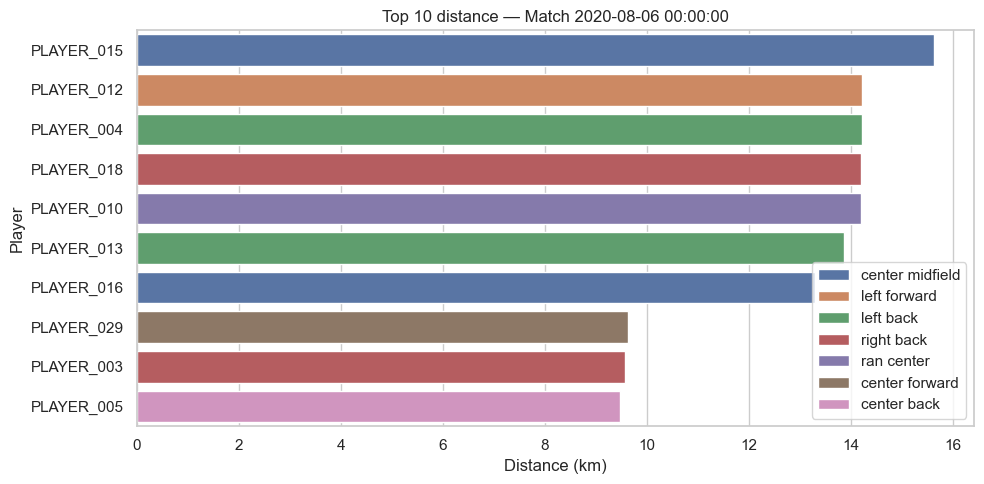

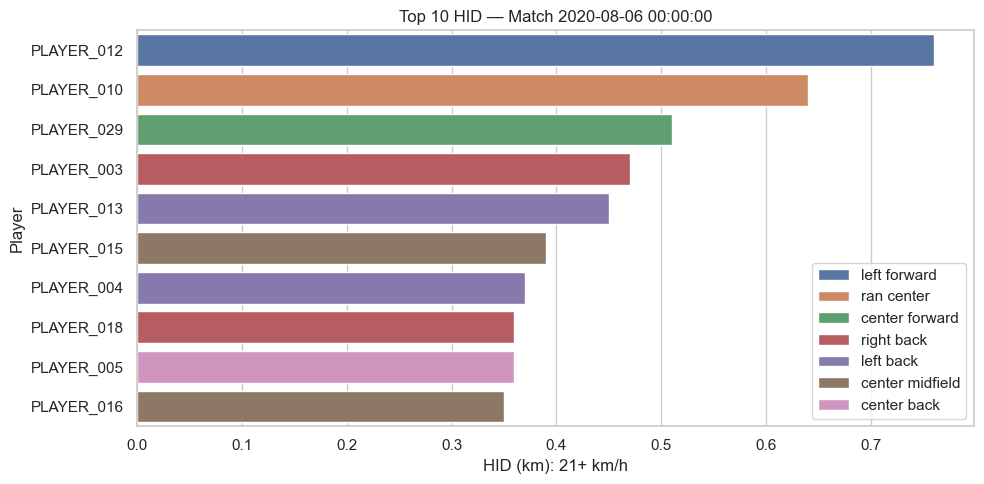

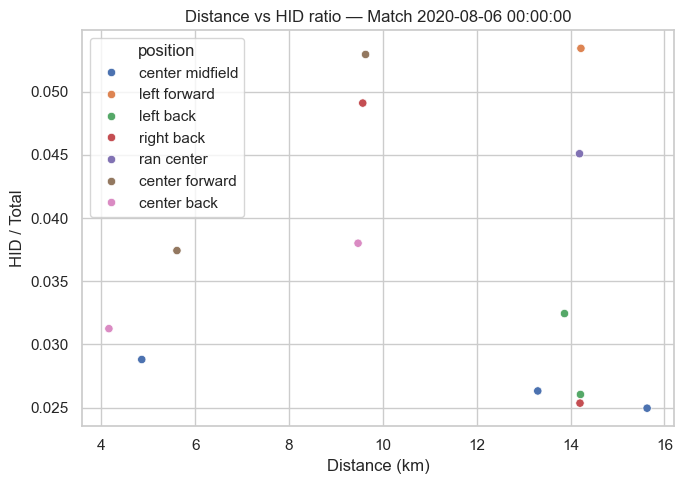

In [31]:
# ---------------------------
# 2) MATCH — SPECIFIC SESSION (auto) (cleaned data)
# ---------------------------

# Auto choice: match with max team distance (on clean data)
best_game = con.execute("""
WITH per_match AS (
  SELECT
    date_trunc('day', session_ts)::DATE AS session_date,
    COUNT(DISTINCT sensor) AS n_players,
    SUM(distance_km) AS team_distance_km,
    SUM(coalesce(d_21_24_km,0) + coalesce(d_24_30_km,0) + coalesce(d_over30_km,0)) AS team_hid_km
  FROM summary_clean
  WHERE session_type='game'
  GROUP BY 1
)
SELECT
  session_date,
  n_players,
  team_distance_km,
  team_hid_km,
  team_hid_km / NULLIF(team_distance_km, 0) AS team_hid_ratio
FROM per_match
ORDER BY team_distance_km DESC NULLS LAST
LIMIT 1;
""").fetchdf()

display(best_game)

game_date = best_game.loc[0, "session_date"]
print("Selected match:", game_date)

# Player table for this match
game_players = con.execute("""
WITH s AS (
  SELECT
    date_trunc('day', session_ts)::DATE AS session_date,
    sensor,
    position,
    distance_km,
    max_speed_kmh,
    coalesce(acc_3mss, 0) AS acc_3mss,
    coalesce(dec_3mss, 0) AS dec_3mss,
    (coalesce(d_21_24_km,0) + coalesce(d_24_30_km,0) + coalesce(d_over30_km,0)) AS hid_km,
    CASE
      WHEN distance_km IS NULL OR distance_km <= 0 THEN NULL
      ELSE (coalesce(d_21_24_km,0) + coalesce(d_24_30_km,0) + coalesce(d_over30_km,0)) / distance_km
    END AS hid_ratio
  FROM summary_clean
  WHERE session_type='game'
)
SELECT
  s.session_date,
  s.sensor,
  p.last_name,
  p.first_name,
  s.position,
  s.distance_km,
  s.hid_km,
  s.hid_ratio,
  s.max_speed_kmh,
  s.acc_3mss,
  s.dec_3mss
FROM s
LEFT JOIN players p USING(sensor)
WHERE s.session_date = ?
ORDER BY s.distance_km DESC NULLS LAST;
""", [game_date]).fetchdf()

display(game_players.head(15))

print("Number of players (rows):", len(game_players))
print("Number of unique sensors:", game_players["sensor"].nunique())
print("Team distance (km):", np.nan_to_num(game_players["distance_km"]).sum())
print("Team HID (km):", np.nan_to_num(game_players["hid_km"]).sum())

# Top players
top10_distance = game_players.sort_values("distance_km", ascending=False).head(10)
top10_hid = game_players.sort_values("hid_km", ascending=False).head(10)

display(top10_distance[["sensor","last_name","first_name","position","distance_km","hid_km","max_speed_kmh"]])
display(top10_hid[["sensor","last_name","first_name","position","hid_km","distance_km","max_speed_kmh"]])

# Summary by position
by_position = (
    game_players
    .groupby("position", dropna=False)
    .agg(
        n_players=("sensor", "nunique"),
        avg_distance_km=("distance_km", "mean"),
        sum_distance_km=("distance_km", "sum"),
        avg_hid_ratio=("hid_ratio", "mean"),
        avg_max_speed=("max_speed_kmh", "mean"),
    )
    .sort_values("sum_distance_km", ascending=False)
    .reset_index()
)
display(by_position)

# Charts
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_distance, y="last_name", x="distance_km", hue="position", dodge=False)
plt.title(f"Top 10 distance — Match {game_date}")
plt.xlabel("Distance (km)")
plt.ylabel("Player")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_hid, y="last_name", x="hid_km", hue="position", dodge=False)
plt.title(f"Top 10 HID — Match {game_date}")
plt.xlabel("HID (km): 21+ km/h")
plt.ylabel("Player")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=game_players, x="distance_km", y="hid_ratio", hue="position")
plt.title(f"Distance vs HID ratio — Match {game_date}")
plt.xlabel("Distance (km)")
plt.ylabel("HID / Total")
plt.tight_layout()
plt.show()

## 3) Training — team overview (practice global)

### Objective
This part aims to **quantify the external training load** and its **variability**, then **position it relative to match demands**:
- **Volume**: how much the team runs (km).
- **Intensity**: what share is done at high speed (HID, ≥ 21 km/h).
- **Effort density**: intense accelerations/decelerations (≥ 3 m/s²).
- **Speed exposure**: max speeds reached (average vs peak).
- **Match benchmark**: does training (average / “hard” sessions) get close to match demands?
- **Stability**: is the load regular or highly fluctuating (week / month)?

---

## Data used (what the code pulls exactly)

### Training sessions
The code starts from the cleaned view `summary_clean` and keeps:
- `session_type = 'practice'`
- non-null `distance_km` and **≥ 0.1 km** (`PRACTICE_MIN_DISTANCE_KM = 0.1`)  
  → removes “near-zero” lines (noise / very low exposure).
- `max_speed_kmh` **≤ 40 km/h** (or `NULL`) (`MAX_SPEED_KMH = 40.0`)  
  → anti-outlier sensor filter.

To avoid missing values breaking team sums, the code replaces with 0 (`coalesce(...,0)`):
- `acc_3mss`, `dec_3mss`
- zone distances `d_0_5_km` … `d_over30_km`

### Matches (for comparison)
Same logic, but on:
- `session_type IN ('game','match')`
- non-null `distance_km` and **≥ 0.5 km** by default (`GAME_MIN_DISTANCE_KM`, reuses `MIN_MATCH_DISTANCE_KM` if it exists)
- `max_speed_kmh` **≤ 40 km/h** (same cap as training)

---

## Computed KPIs (definitions + practical meaning)

### 1) Volume
- Player: `distance_km`
- Team / session: `team_distance_km = sum(distance_km)`

Club reading:
- macro indicator of session volume,
- **depends on squad size** (more players → larger team sum).

### 2) Intensity: HID (≥ 21 km/h)
Definition used:
- `hid_km = d_21_24_km + d_24_30_km + d_over30_km`
- `hid_ratio = hid_km / distance_km` (if distance > 0)
- Team:
  - `team_hid_km = sum(hid_km)`
  - `team_hid_ratio = team_hid_km / team_distance_km`

Club reading:
- `team_hid_ratio` = **share of fast running** in the session (intensity content),
- ratio weighted by total volume.

### 3) Effort density: intense accelerations / decelerations
- `team_acc_3mss = sum(acc_3mss)`
- `team_dec_3mss = sum(dec_3mss)`

Club reading:
- reflects a “speed-change / neuromuscular” load (useful to distinguish volume vs density).

### 4) Speed exposure
- `avg_player_max_speed_kmh`: average of individual vmax values (global exposure)
- `max_player_max_speed_kmh`: highest vmax of the day (peak exposure)

### 5) Session content: speed zones
- Team sums: `team_d_0_5_km` … `team_d_over30_km`

Club reading:
- shows **how** volume is built (low-speed dominant vs meaningful high-speed content).

---

## Aggregation by session (what `practice_team_by_day` represents)
The code groups by `session_date` and computes:
- `n_players`: number of players (sensors) present
- `team_*`: **team sums** (except speeds: mean and max)

Key staff point:
- if `n_players` changes, `team_*` KPIs change too, even if the session is identical.

---

## “Practice global” visualizations (how to read the charts)

### A) Time series (4 charts)
1) Team total distance → volume
2) HID share (%) → relative intensity
3) Team acc/dec → effort density
4) Max speed (average vs peak) → speed exposure

Quick rules of thumb:
- Distance ↑ but HID% ↓: more “volume” session
- Distance stable but acc/dec ↑: denser session (small-sided games, transitions…)
- Speed peak ↑ without HID increase: punctuated exposure (a few sprints), not necessarily large fast-running volume

### B) Speed zones (stacked bars)
- If many sessions, aggregate **by month** (more readable); otherwise **by session**.

### C) Boxplots by position (players)
- `distance_km`, `hid_ratio`, `max_speed_kmh` by position  
→ role consistency + detection of extremes/variability.

---

# 3D) Training vs match + variability (club)

## Why add “per-player” KPIs (to neutralize squad size)
To compare sessions with different squad sizes, the code computes:
- `distance_pp_km = team_distance_km / n_players`
- `hid_pp_km = team_hid_km / n_players`
- `acc_pp = team_acc_3mss / n_players`
- `dec_pp = team_dec_3mss / n_players`

Club reading:
- these KPIs are the most robust to compare **training vs match** at a global level.

## Training vs match comparison: means + percentiles
The code puts training sessions and matches into a common table, then computes for each KPI:
- `mean`, `p25`, `median`, `p75`, `p90`, and `n_sessions`

Why percentiles:
- `p90` describes the “top 10%” sessions → useful to check whether your hardest sessions approach match demands.

Associated visualizations (boxplots):
- `distance_pp_km`: km / player / session (training vs match)
- `hid_pp_km`: HID km / player / session (training vs match)

## Variability / stability: by week and by month (training)
The code measures planning regularity across training sessions:
- **Weekly** aggregation (`week = W-MON`):
  - `weekly_distance_km` (weekly volume)
  - intra-week variability via a **CV** (coefficient of variation):
    - $CV = \sigma / \mu$ on `team_distance_km`, `team_hid_ratio`, `team_acc_3mss`
- **Monthly** aggregation (`month`):
  - `monthly_distance_km`
  - CV on `team_distance_km` and `team_hid_ratio`

Club reading:
- **low CV** → homogeneous weeks/months (similar sessions)
- **high CV** → more contrasted planning (recovery + very hard sessions, strong variation)

---

## Points of attention (avoid wrong conclusions)
- `team_*` KPIs are **sums**: sensitive to squad size (`n_players`).
- To compare training vs match, prefer **per-player** KPIs (`*_pp_*`).
- `coalesce(...,0)` allows safe sums; a missing value is treated as 0.
- The `max_speed_kmh <= 40` filter protects against sensor outliers; a miscalibrated value may be excluded.

,session_date,n_players,team_distance_km,team_hid_km,team_acc_3mss,team_dec_3mss,avg_player_max_speed_kmh,max_player_max_speed_kmh,team_d_0_5_km,team_d_5_10_km,team_d_10_15_km,team_d_15_21_km,team_d_21_24_km,team_d_24_30_km,team_d_over30_km,team_hid_ratio
0,2019-07-04,21,104.86,2.84,799.0,418.0,22.124286,26.10,42.72,45.33,7.47,6.52,2.74,0.10,0.00,0.027084
1,2019-07-05,14,82.12,2.01,931.0,623.0,27.242857,30.59,39.11,22.90,11.33,6.77,1.40,0.60,0.01,0.024476
2,2019-07-06,21,200.57,3.51,2162.0,1383.0,24.825714,27.66,72.39,57.87,30.74,36.06,3.16,0.35,0.00,0.017500
3,2019-07-08,21,87.12,0.87,497.0,234.0,24.992857,36.88,43.78,28.50,10.22,3.72,0.55,0.27,0.05,0.009986
4,2019-07-10,19,72.61,0.12,467.0,291.0,16.291053,25.10,20.31,44.31,6.25,1.58,0.11,0.01,0.00,0.001653
5,2019-07-11,19,56.78,0.14,549.0,257.0,19.772632,23.54,29.24,19.73,5.32,2.40,0.14,0.00,0.00,0.002466
6,2019-07-12,4,11.60,2.75,347.0,120.0,24.947500,26.25,3.07,1.29,1.06,3.41,2.57,0.18,0.00,0.237069
7,2019-07-16,13,61.26,0.58,439.0,550.0,25.346923,29.76,26.88,19.38,10.90,3.51,0.40,0.18,0.00,0.009468
8,2019-07-17,20,148.08,2.65,1203.0,1046.0,26.166000,28.23,70.37,45.41,21.77,7.85,1.84,0.81,0.00,0.017896
9,2019-07-18,18,59.31,0.64,234.0,163.0,25.130556,36.73,32.92,18.53,4.65,2.50,0.42,0.21,0.01,0.010791


Number of training days: 184


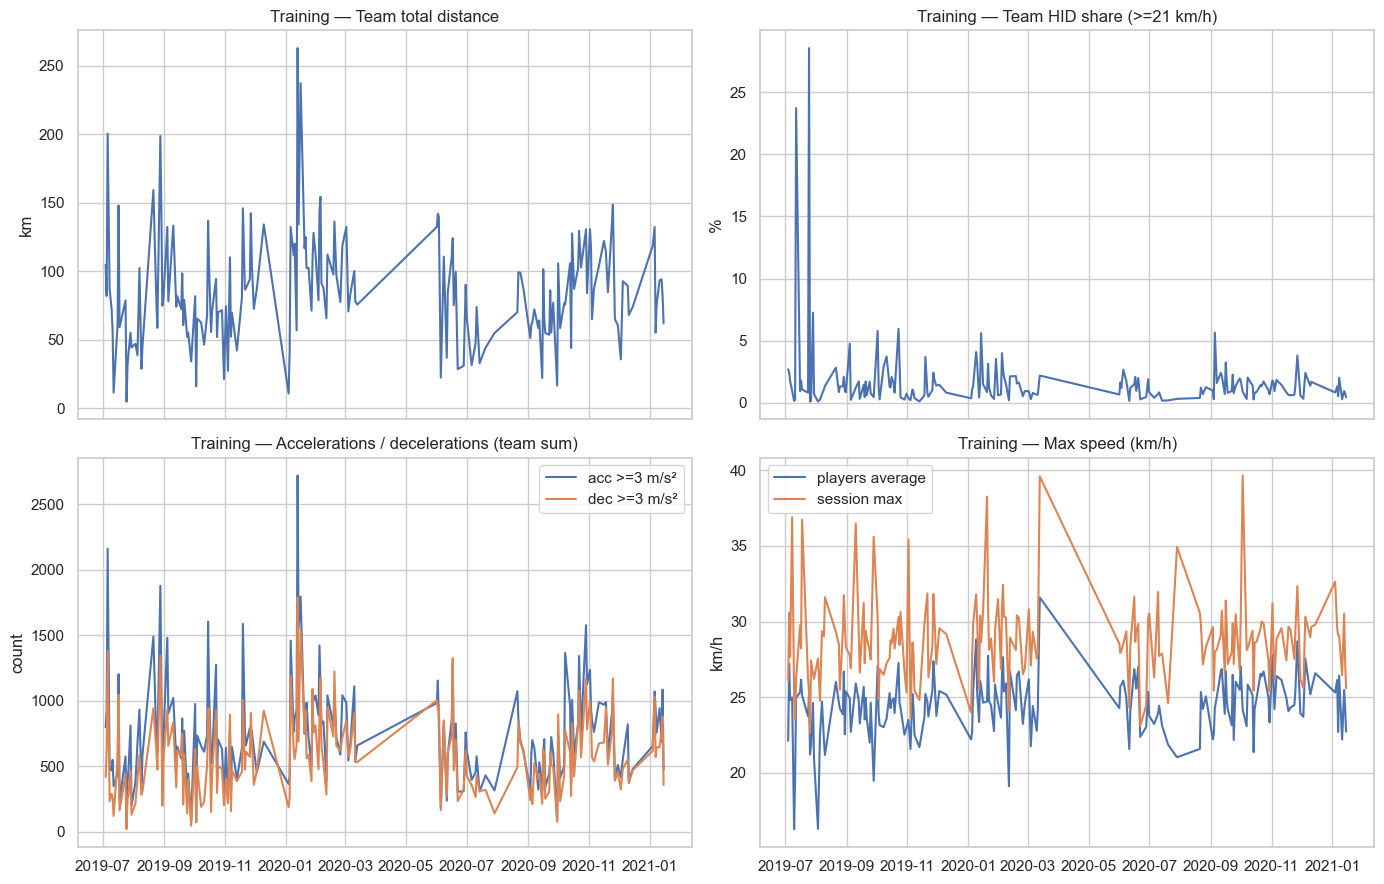

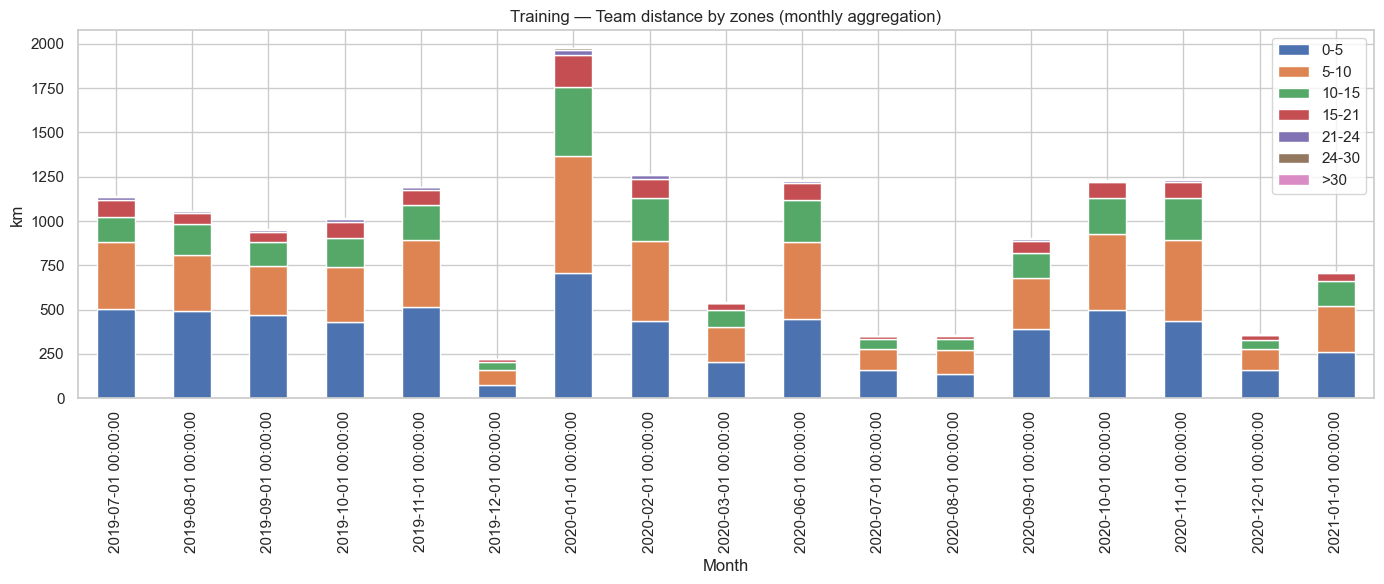

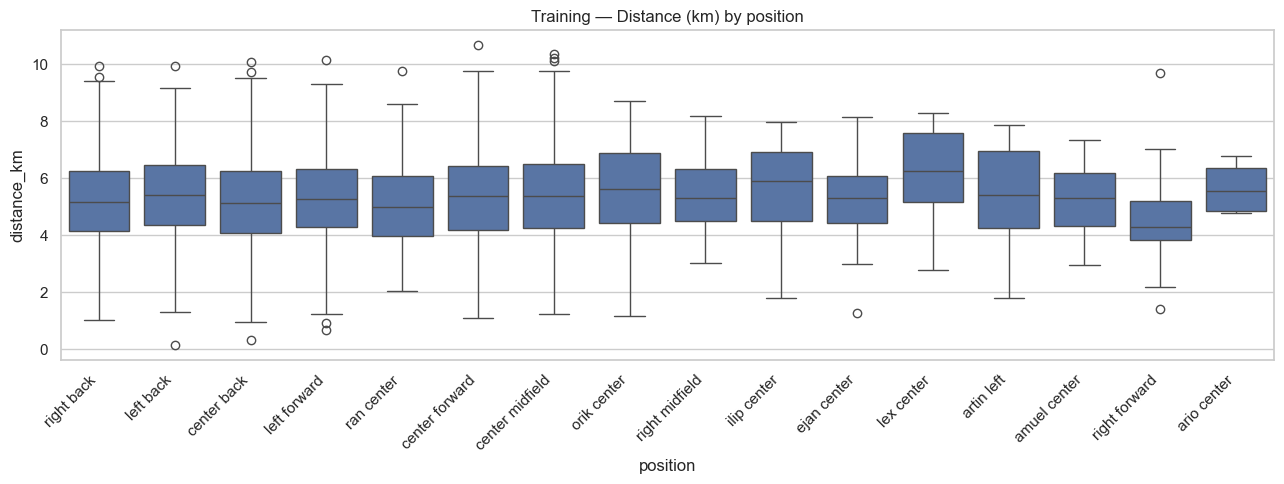

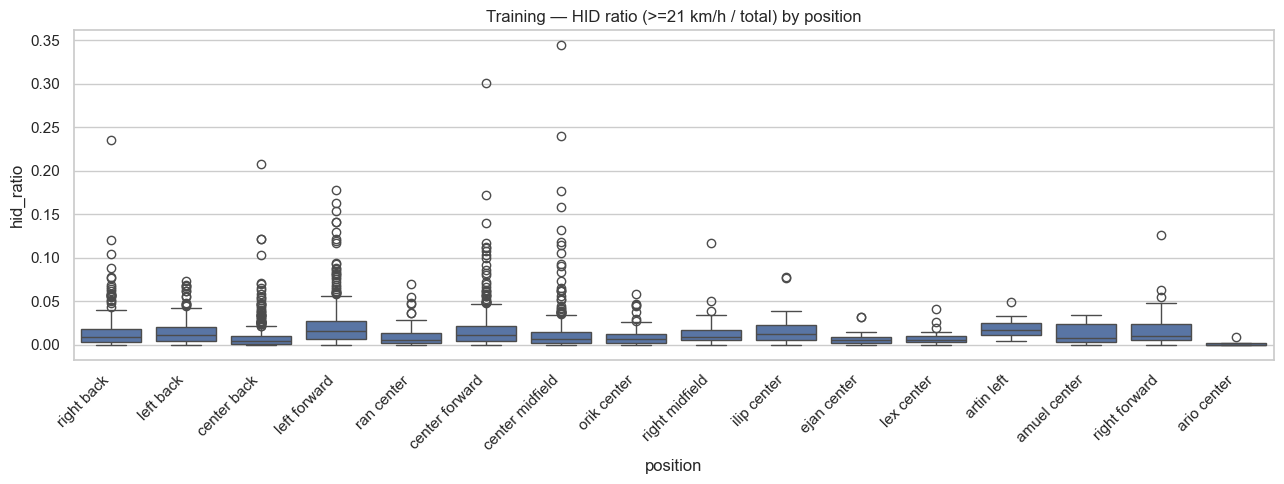

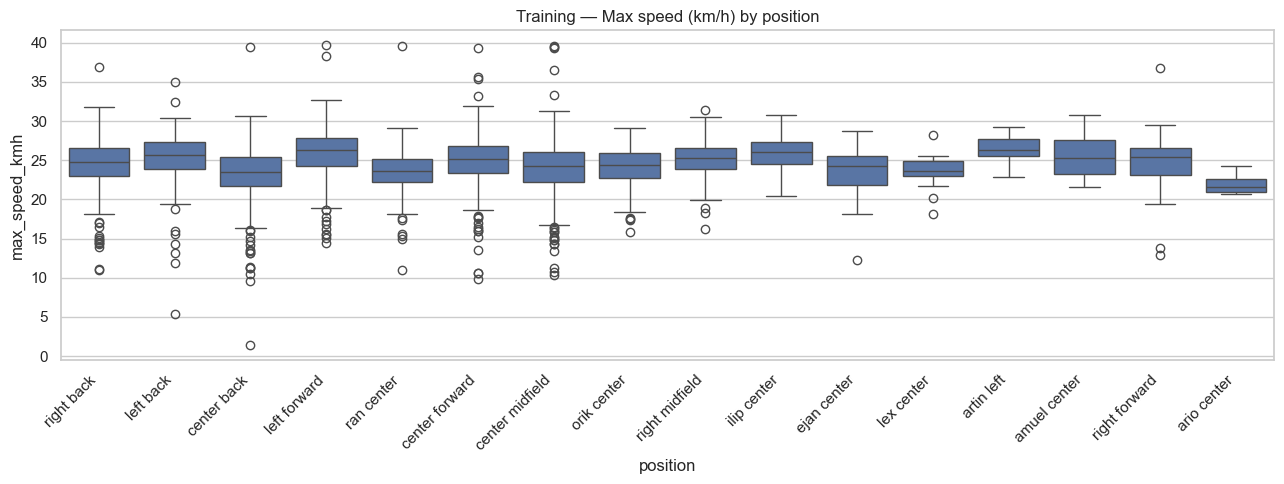

,session_type,metric,mean,p25,median,p75,p90,n_sessions
0,match,acc_pp,58.399844,51.900000,57.692308,65.333333,71.384615,73
10,practice,acc_pp,48.703760,35.128483,44.941176,56.317810,75.071493,184
1,match,avg_player_max_speed_kmh,28.765077,28.306923,28.815714,29.331429,29.657500,73
11,practice,avg_player_max_speed_kmh,24.472341,23.323768,24.656026,25.734761,26.701937,184
2,match,dec_pp,70.933710,62.437500,71.615385,79.153846,87.025641,73
12,practice,dec_pp,37.382179,27.696875,36.222619,46.055556,59.381731,184
3,match,distance_pp_km,8.050458,7.628462,8.296154,8.852500,9.340667,73
13,practice,distance_pp_km,5.431144,4.210735,5.140176,6.421148,7.438364,184
4,match,hid_pp_km,0.314274,0.260769,0.315833,0.366154,0.393795,73
14,practice,hid_pp_km,0.090030,0.030469,0.058452,0.112412,0.191270,184


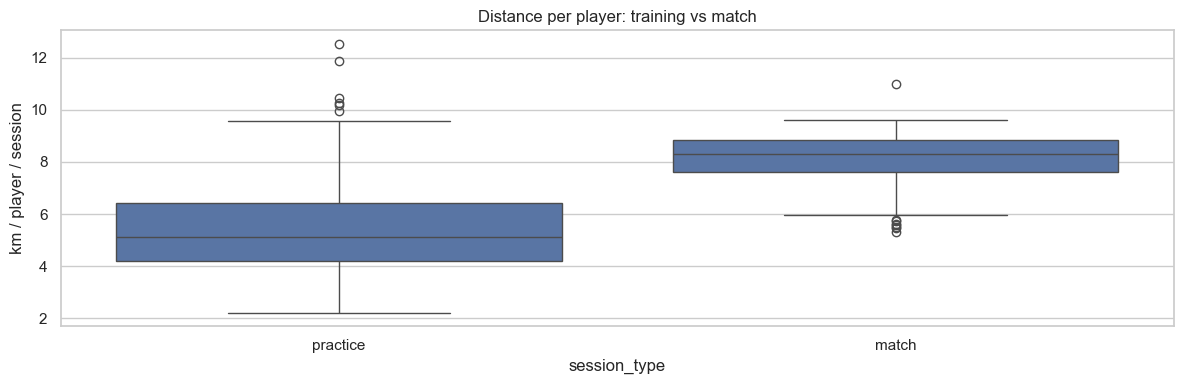

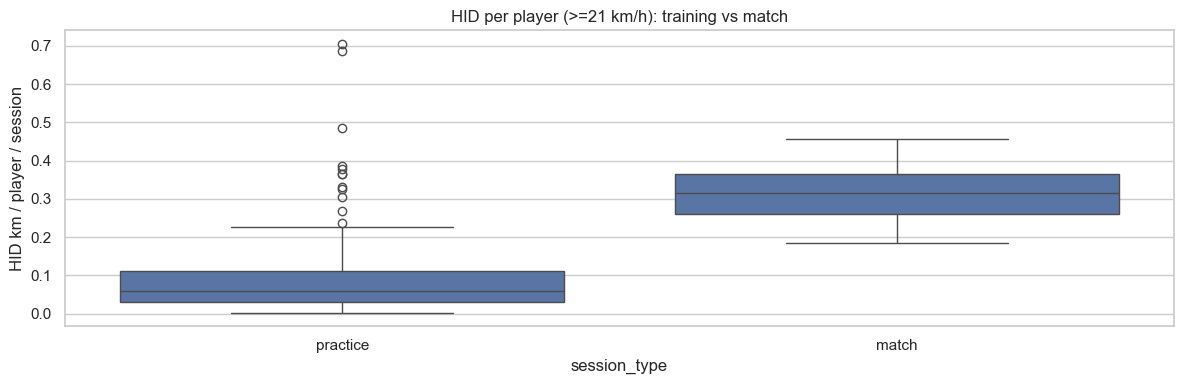

,week,n_sessions,weekly_distance_km,mean_session_distance_km,sd_session_distance_km,mean_session_hid_ratio,sd_session_hid_ratio,mean_session_acc,sd_session_acc,cv_session_distance,cv_session_hid_ratio,cv_session_acc
0,2019-07-02,4,474.67,118.667500,55.466600,0.019762,0.007671,1097.250000,732.708389,0.467412,0.388157,0.667768
1,2019-07-09,3,140.99,46.996667,31.659757,0.080396,0.135684,454.333333,101.593963,0.673660,1.687696,0.223611
2,2019-07-16,3,268.65,89.550000,50.697843,0.012718,0.004532,625.333333,510.666558,0.566140,0.356380,0.816631
3,2019-07-23,5,210.84,42.168000,27.500218,0.073851,0.122014,464.600000,268.835080,0.652158,1.652161,0.578638
4,2019-07-30,3,130.57,43.523333,4.302468,0.003608,0.003192,418.666667,241.711260,0.098854,0.884818,0.577336
...,...,...,...,...,...,...,...,...,...,...,...,...
59,2020-12-08,2,157.65,78.825000,15.011877,0.015379,0.002301,604.000000,305.470129,0.190446,0.149615,0.505745
60,2020-12-15,1,74.25,74.250000,NaN,0.015488,NaN,479.000000,NaN,NaN,NaN,NaN
61,2020-12-29,1,118.57,118.570000,NaN,0.008434,NaN,654.000000,NaN,NaN,NaN,NaN
62,2021-01-05,4,357.19,89.297500,32.720791,0.010462,0.007853,925.750000,129.438209,0.366424,0.750584,0.139820


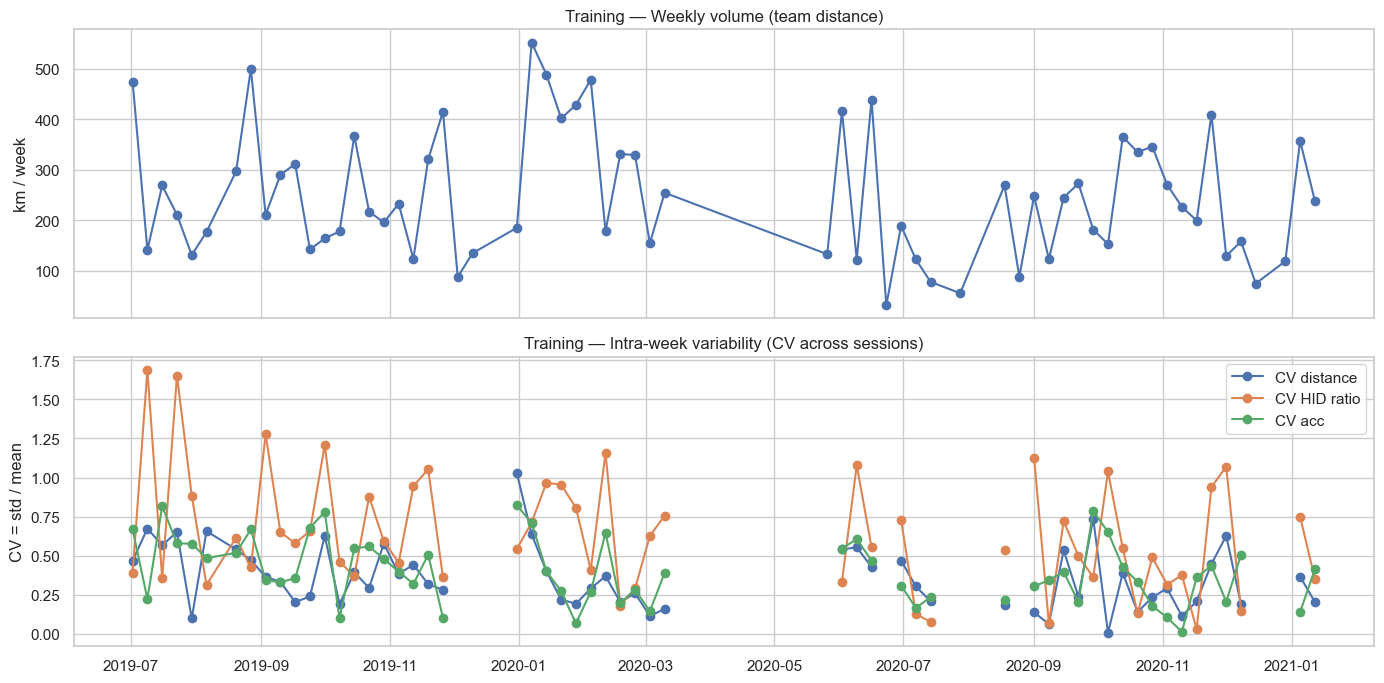

,month,n_sessions,monthly_distance_km,mean_session_distance_km,sd_session_distance_km,mean_session_hid_ratio,sd_session_hid_ratio,cv_session_distance,cv_session_hid_ratio
0,2019-07-01,16,1139.67,71.229375,49.062016,0.045927,0.086255,0.688789,1.878083
1,2019-08-01,12,1058.66,88.221667,53.561064,0.011498,0.007467,0.607119,0.649380
2,2019-09-01,12,953.77,79.480833,29.989425,0.012932,0.012357,0.377316,0.955513
3,2019-10-01,15,1018.28,67.885333,30.062496,0.021024,0.018523,0.442842,0.881044
4,2019-11-01,14,1193.27,85.233571,33.862447,0.010989,0.009895,0.397290,0.900463
5,2019-12-01,2,221.63,110.815000,33.283516,0.011406,0.004447,0.300352,0.389859
6,2020-01-01,17,1976.93,116.290000,61.097893,0.018565,0.015342,0.525392,0.826402
7,2020-02-01,12,1263.03,105.252500,28.217230,0.016898,0.010539,0.268091,0.623673
8,2020-03-01,6,540.95,90.158333,23.079149,0.009293,0.006574,0.255985,0.707411
9,2020-06-01,14,1230.20,87.871429,42.907642,0.013257,0.007471,0.488300,0.563529


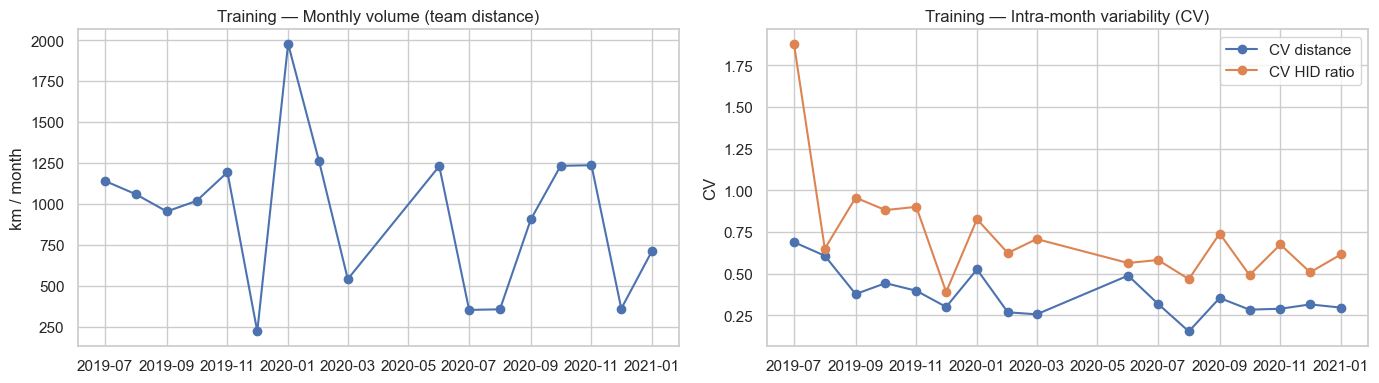

In [32]:
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 3) TRAINING — TEAM OVERVIEW (practice global)
# + 3D) TRAINING vs MATCH + VARIABILITY (club)
# ---------------------------

# Consistent parameters (used everywhere)
PRACTICE_MIN_DISTANCE_KM = 0.1
MAX_SPEED_KMH = 40.0

# For matches: reuse the same speed ceiling
GAME_MIN_DISTANCE_KM = float(globals().get("MIN_MATCH_DISTANCE_KM", 0.5))
GAME_MAX_SPEED_KMH = MAX_SPEED_KMH

# ---------------------------
# A) Extraction + player KPIs (practice)
# ---------------------------
practice_players = con.execute("""
SELECT
  date_trunc('day', session_ts)::DATE AS session_date,
  sensor,
  position,
  distance_km,
  max_speed_kmh,
  coalesce(acc_3mss, 0) AS acc_3mss,
  coalesce(dec_3mss, 0) AS dec_3mss,

  coalesce(d_0_5_km, 0) AS d_0_5_km,
  coalesce(d_5_10_km, 0) AS d_5_10_km,
  coalesce(d_10_15_km, 0) AS d_10_15_km,
  coalesce(d_15_21_km, 0) AS d_15_21_km,
  coalesce(d_21_24_km, 0) AS d_21_24_km,
  coalesce(d_24_30_km, 0) AS d_24_30_km,
  coalesce(d_over30_km, 0) AS d_over30_km
FROM summary_clean
WHERE session_type = 'practice'
  AND distance_km IS NOT NULL
  AND distance_km >= ?
  AND (max_speed_kmh IS NULL OR max_speed_kmh <= ?);
""", [PRACTICE_MIN_DISTANCE_KM, MAX_SPEED_KMH]).fetchdf()

practice_players["hid_km"] = (
    practice_players["d_21_24_km"] + practice_players["d_24_30_km"] + practice_players["d_over30_km"]
)
practice_players["hid_ratio"] = np.where(
    practice_players["distance_km"] > 0,
    practice_players["hid_km"] / practice_players["distance_km"],
    np.nan
)

# ---------------------------
# B) Team/session aggregation (practice)
# ---------------------------
practice_team_by_day = (
    practice_players
    .groupby("session_date", as_index=False)
    .agg(
        n_players=("sensor", "nunique"),
        team_distance_km=("distance_km", "sum"),
        team_hid_km=("hid_km", "sum"),
        team_acc_3mss=("acc_3mss", "sum"),
        team_dec_3mss=("dec_3mss", "sum"),
        avg_player_max_speed_kmh=("max_speed_kmh", "mean"),
        max_player_max_speed_kmh=("max_speed_kmh", "max"),

        team_d_0_5_km=("d_0_5_km", "sum"),
        team_d_5_10_km=("d_5_10_km", "sum"),
        team_d_10_15_km=("d_10_15_km", "sum"),
        team_d_15_21_km=("d_15_21_km", "sum"),
        team_d_21_24_km=("d_21_24_km", "sum"),
        team_d_24_30_km=("d_24_30_km", "sum"),
        team_d_over30_km=("d_over30_km", "sum"),
    )
    .sort_values("session_date")
)

practice_team_by_day["team_hid_ratio"] = (
    practice_team_by_day["team_hid_km"] /
    practice_team_by_day["team_distance_km"].replace({0: np.nan})
)
practice_team_by_day["session_date"] = pd.to_datetime(practice_team_by_day["session_date"])

display(practice_team_by_day.head(10))
print("Number of training days:", practice_team_by_day["session_date"].nunique())

# ---------------------------
# C) Practice charts (overview)
# ---------------------------

# C1) Time series
fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

ax[0, 0].plot(practice_team_by_day["session_date"], practice_team_by_day["team_distance_km"])
ax[0, 0].set_title("Training — Team total distance")
ax[0, 0].set_ylabel("km")

ax[0, 1].plot(practice_team_by_day["session_date"], 100 * practice_team_by_day["team_hid_ratio"])
ax[0, 1].set_title("Training — Team HID share (>=21 km/h)")
ax[0, 1].set_ylabel("%")

ax[1, 0].plot(practice_team_by_day["session_date"], practice_team_by_day["team_acc_3mss"], label="acc >=3 m/s²")
ax[1, 0].plot(practice_team_by_day["session_date"], practice_team_by_day["team_dec_3mss"], label="dec >=3 m/s²")
ax[1, 0].set_title("Training — Accelerations / decelerations (team sum)")
ax[1, 0].set_ylabel("count")
ax[1, 0].legend()

ax[1, 1].plot(practice_team_by_day["session_date"], practice_team_by_day["avg_player_max_speed_kmh"], label="players average")
ax[1, 1].plot(practice_team_by_day["session_date"], practice_team_by_day["max_player_max_speed_kmh"], label="session max")
ax[1, 1].set_title("Training — Max speed (km/h)")
ax[1, 1].set_ylabel("km/h")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

# C2) Speed zones (aggregate by month if many sessions)
zones_cols = [
    "team_d_0_5_km", "team_d_5_10_km", "team_d_10_15_km",
    "team_d_15_21_km", "team_d_21_24_km", "team_d_24_30_km", "team_d_over30_km"
]
zones_labels = ["0-5", "5-10", "10-15", "15-21", "21-24", "24-30", ">30"]

zones = practice_team_by_day[["session_date"] + zones_cols].copy()
zones = zones.rename(columns=dict(zip(zones_cols, zones_labels)))

if len(zones) > 25:
    zones["month"] = zones["session_date"].dt.to_period("M").dt.to_timestamp()
    zones_plot = zones.groupby("month")[zones_labels].sum()
    xlab = "Month"
    title = "Training — Team distance by zones (monthly aggregation)"
else:
    zones_plot = zones.set_index("session_date")[zones_labels]
    xlab = "Session"
    title = "Training — Team distance by zones (per session)"

ax = zones_plot.plot(kind="bar", stacked=True, figsize=(14, 6))
ax.set_title(title)
ax.set_xlabel(xlab)
ax.set_ylabel("km")
plt.tight_layout()
plt.show()

# C3) Spread by position (players)
plt.figure(figsize=(13, 5))
sns.boxplot(data=practice_players, x="position", y="distance_km")
plt.xticks(rotation=45, ha="right")
plt.title("Training — Distance (km) by position")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 5))
sns.boxplot(data=practice_players, x="position", y="hid_ratio")
plt.xticks(rotation=45, ha="right")
plt.title("Training — HID ratio (>=21 km/h / total) by position")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 5))
sns.boxplot(data=practice_players, x="position", y="max_speed_kmh")
plt.xticks(rotation=45, ha="right")
plt.title("Training — Max speed (km/h) by position")
plt.tight_layout()
plt.show()

# ---------------------------
# 3D) TRAINING vs MATCH + VARIABILITY (club)
# ---------------------------

# D1) "Per-player" KPIs (neutralize squad-size effect)
practice_team_by_day = practice_team_by_day.copy()
practice_team_by_day["distance_pp_km"] = practice_team_by_day["team_distance_km"] / practice_team_by_day["n_players"].replace({0: np.nan})
practice_team_by_day["hid_pp_km"] = practice_team_by_day["team_hid_km"] / practice_team_by_day["n_players"].replace({0: np.nan})
practice_team_by_day["acc_pp"] = practice_team_by_day["team_acc_3mss"] / practice_team_by_day["n_players"].replace({0: np.nan})
practice_team_by_day["dec_pp"] = practice_team_by_day["team_dec_3mss"] / practice_team_by_day["n_players"].replace({0: np.nan})

# D2) Build the match equivalent (same KPIs)
game_players_cmp = con.execute("""
SELECT
  date_trunc('day', session_ts)::DATE AS session_date,
  sensor,
  position,
  distance_km,
  max_speed_kmh,
  coalesce(acc_3mss, 0) AS acc_3mss,
  coalesce(dec_3mss, 0) AS dec_3mss,
  coalesce(d_21_24_km, 0) AS d_21_24_km,
  coalesce(d_24_30_km, 0) AS d_24_30_km,
  coalesce(d_over30_km, 0) AS d_over30_km
FROM summary_clean
WHERE session_type IN ('game', 'match')
  AND distance_km IS NOT NULL
  AND distance_km >= ?
  AND (max_speed_kmh IS NULL OR max_speed_kmh <= ?);
""", [GAME_MIN_DISTANCE_KM, GAME_MAX_SPEED_KMH]).fetchdf()

if len(game_players_cmp) == 0:
    print("No matches found in summary_clean with session_type IN ('game','match').")
else:
    game_players_cmp["hid_km"] = (
        game_players_cmp["d_21_24_km"] + game_players_cmp["d_24_30_km"] + game_players_cmp["d_over30_km"]
    )

    game_team_by_day_cmp = (
        game_players_cmp
        .groupby("session_date", as_index=False)
        .agg(
            n_players=("sensor", "nunique"),
            team_distance_km=("distance_km", "sum"),
            team_hid_km=("hid_km", "sum"),
            team_acc_3mss=("acc_3mss", "sum"),
            team_dec_3mss=("dec_3mss", "sum"),
            avg_player_max_speed_kmh=("max_speed_kmh", "mean"),
            max_player_max_speed_kmh=("max_speed_kmh", "max"),
        )
    )
    game_team_by_day_cmp["session_date"] = pd.to_datetime(game_team_by_day_cmp["session_date"])
    game_team_by_day_cmp["team_hid_ratio"] = (
        game_team_by_day_cmp["team_hid_km"] /
        game_team_by_day_cmp["team_distance_km"].replace({0: np.nan})
    )
    game_team_by_day_cmp["distance_pp_km"] = game_team_by_day_cmp["team_distance_km"] / game_team_by_day_cmp["n_players"].replace({0: np.nan})
    game_team_by_day_cmp["hid_pp_km"] = game_team_by_day_cmp["team_hid_km"] / game_team_by_day_cmp["n_players"].replace({0: np.nan})
    game_team_by_day_cmp["acc_pp"] = game_team_by_day_cmp["team_acc_3mss"] / game_team_by_day_cmp["n_players"].replace({0: np.nan})
    game_team_by_day_cmp["dec_pp"] = game_team_by_day_cmp["team_dec_3mss"] / game_team_by_day_cmp["n_players"].replace({0: np.nan})

    # D3) Training vs match stats: means + percentiles
    cols_compare = [
        "team_distance_km", "team_hid_ratio", "team_acc_3mss", "team_dec_3mss",
        "avg_player_max_speed_kmh", "max_player_max_speed_kmh",
        "distance_pp_km", "hid_pp_km", "acc_pp", "dec_pp"
    ]

    comp_pr = practice_team_by_day[["session_date"] + cols_compare].copy()
    comp_pr["session_type"] = "practice"
    comp_ga = game_team_by_day_cmp[["session_date"] + cols_compare].copy()
    comp_ga["session_type"] = "match"

    comp = pd.concat([comp_pr, comp_ga], ignore_index=True)

    def summarize_series(s: pd.Series) -> dict:
        s = s.dropna()
        if len(s) == 0:
            return {"mean": np.nan, "p25": np.nan, "median": np.nan, "p75": np.nan, "p90": np.nan}
        return {
            "mean": float(s.mean()),
            "p25": float(s.quantile(0.25)),
            "median": float(s.median()),
            "p75": float(s.quantile(0.75)),
            "p90": float(s.quantile(0.90)),
        }

    rows = []
    melted = comp.melt(id_vars=["session_type", "session_date"], value_vars=cols_compare)
    for (t, metric), g in melted.groupby(["session_type", "variable"]):
        stats = summarize_series(g["value"])
        rows.append({"session_type": t, "metric": metric, **stats, "n_sessions": g["session_date"].nunique()})

    comp_stats = pd.DataFrame(rows).sort_values(["metric", "session_type"])
    display(comp_stats)

    # D4) Distributions (focus on per-player KPIs)
    plt.figure(figsize=(12, 4))
    sns.boxplot(data=comp, x="session_type", y="distance_pp_km")
    plt.title("Distance per player: training vs match")
    plt.ylabel("km / player / session")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    sns.boxplot(data=comp, x="session_type", y="hid_pp_km")
    plt.title("HID per player (>=21 km/h): training vs match")
    plt.ylabel("HID km / player / session")
    plt.tight_layout()
    plt.show()

    # D5) Variability / stability: weeks and months (training)
    pr = practice_team_by_day.sort_values("session_date").copy()
    pr["week"] = pr["session_date"].dt.to_period("W-MON").dt.start_time
    pr["month"] = pr["session_date"].dt.to_period("M").dt.to_timestamp()

    weekly = (
        pr.groupby("week", as_index=False)
        .agg(
            n_sessions=("session_date", "nunique"),
            weekly_distance_km=("team_distance_km", "sum"),
            mean_session_distance_km=("team_distance_km", "mean"),
            sd_session_distance_km=("team_distance_km", "std"),
            mean_session_hid_ratio=("team_hid_ratio", "mean"),
            sd_session_hid_ratio=("team_hid_ratio", "std"),
            mean_session_acc=("team_acc_3mss", "mean"),
            sd_session_acc=("team_acc_3mss", "std"),
        )
    )
    weekly["cv_session_distance"] = weekly["sd_session_distance_km"] / weekly["mean_session_distance_km"].replace({0: np.nan})
    weekly["cv_session_hid_ratio"] = weekly["sd_session_hid_ratio"] / weekly["mean_session_hid_ratio"].replace({0: np.nan})
    weekly["cv_session_acc"] = weekly["sd_session_acc"] / weekly["mean_session_acc"].replace({0: np.nan})

    display(weekly.sort_values("week"))

    fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    ax[0].plot(weekly["week"], weekly["weekly_distance_km"], marker="o")
    ax[0].set_title("Training — Weekly volume (team distance)")
    ax[0].set_ylabel("km / week")

    ax[1].plot(weekly["week"], weekly["cv_session_distance"], marker="o", label="CV distance")
    ax[1].plot(weekly["week"], weekly["cv_session_hid_ratio"], marker="o", label="CV HID ratio")
    ax[1].plot(weekly["week"], weekly["cv_session_acc"], marker="o", label="CV acc")
    ax[1].set_title("Training — Intra-week variability (CV across sessions)")
    ax[1].set_ylabel("CV = std / mean")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    monthly = (
        pr.groupby("month", as_index=False)
        .agg(
            n_sessions=("session_date", "nunique"),
            monthly_distance_km=("team_distance_km", "sum"),
            mean_session_distance_km=("team_distance_km", "mean"),
            sd_session_distance_km=("team_distance_km", "std"),
            mean_session_hid_ratio=("team_hid_ratio", "mean"),
            sd_session_hid_ratio=("team_hid_ratio", "std"),
        )
    )
    monthly["cv_session_distance"] = monthly["sd_session_distance_km"] / monthly["mean_session_distance_km"].replace({0: np.nan})
    monthly["cv_session_hid_ratio"] = monthly["sd_session_hid_ratio"] / monthly["mean_session_hid_ratio"].replace({0: np.nan})

    display(monthly.sort_values("month"))

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(monthly["month"], monthly["monthly_distance_km"], marker="o")
    ax[0].set_title("Training — Monthly volume (team distance)")
    ax[0].set_ylabel("km / month")

    ax[1].plot(monthly["month"], monthly["cv_session_distance"], marker="o", label="CV distance")
    ax[1].plot(monthly["month"], monthly["cv_session_hid_ratio"], marker="o", label="CV HID ratio")
    ax[1].set_title("Training — Intra-month variability (CV)")
    ax[1].set_ylabel("CV")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

## 4) Training — specific session (practice specific)

### Objective
This section **zooms in on one specific training session** to move from “global” to an **operational** reading:
- characterize the session (more **volume**, more **HID intensity**, or more **dense** via acc/dec),
- identify the most loaded players (volume) and the most exposed players (high speed),
- compare profiles by position on **the same session**.

---

### 4A) Automatic selection of the analyzed session (`best_practice`)
The code automatically chooses a session to analyze: **the one with the highest team total distance**.

**How the SQL query works**
1) It aggregates `summary_clean` **by day** (CTE `per_sess`) for training sessions:
- `session_date`: session date (day)
- `n_players`: number of players present (`COUNT(DISTINCT sensor)`)
- `team_distance_km`: sum of all players’ distances
- `team_hid_km`: sum of high-intensity distance (≥ 21 km/h):
  - `d_21_24_km + d_24_30_km + d_over30_km`

2) It applies quality filters (consistent with the rest of the notebook):
- `session_type='practice'`
- non-null `distance_km` and `distance_km >= PRACTICE_MIN_DISTANCE_KM`
- `max_speed_kmh <= MAX_SPEED_KMH` (or `NULL`)

3) It then computes:
- `team_hid_ratio = team_hid_km / team_distance_km`  
  (with `NULLIF(team_distance_km, 0)` to avoid division by zero)

4) It sorts and selects:
- `ORDER BY team_distance_km DESC`
- `LIMIT 1`  
→ the selected session is therefore the most **“voluminous”** in team distance.

**Club interpretation**
- this is a simple choice to illustrate a high-volume session.
- it is not necessarily the most intense session (HID ratio) nor the densest (acc/dec).

---

### 4B) Extracting players for the selected day (`practice_day_players`)
Once `practice_date` is identified, the code extracts **all players** from that day and computes their individual KPIs.

**What the SQL block computes (CTE `s`)**
For each player and each day:
- `distance_km`
- `max_speed_kmh`
- `acc_3mss` and `dec_3mss` (with `coalesce(...,0)` if missing)
- `hid_km = d_21_24_km + d_24_30_km + d_over30_km`
- `hid_ratio = hid_km / distance_km` only if `distance_km > 0` (otherwise `NULL`)

Then:
- `LEFT JOIN players` to retrieve `last_name` and `first_name` from the sensor (`sensor`)
- filter `WHERE s.session_date = practice_date`
- sort `ORDER BY s.distance_km DESC` (highest volumes first)

**Club interpretation**
- this is the “session sheet”: who took the most volume, the most HID, who hit the highest speeds, etc.

---

### 4C) Produced charts (how to read them)

#### 1) Top 10 distance (barplot)
The code builds `top10_practice_dist` (10 highest distances) and plots:
- X-axis: `distance_km`
- Y-axis: `last_name`
- color: `position`

**Staff reading**
- identifies the most loaded players in **volume** for that session,
- useful to spot potential overload or under-exposure.

#### 2) Top 10 HID (barplot)
The code builds `top10_practice_hid` (10 highest HID) and plots:
- X-axis: `hid_km` (km at ≥ 21 km/h)
- Y-axis: `last_name`
- color: `position`

**Staff reading**
- identifies the players most exposed to **high intensity / high speed**,
- helps verify whether some roles (wide players, forwards, full-backs) receive the expected exposure.

#### 3) Distance vs HID ratio (scatter)
Each point = 1 player in the session:
- X-axis: `distance_km` (volume)
- Y-axis: `hid_ratio` (high-intensity share)
- color: `position`

**Quick reading**
- **top-right**: high volume + high intensity (very demanding for that player)
- **bottom-right**: high volume but low relative intensity (more “aerobic / volume”)
- **top-left**: high relative intensity but low volume (short high-speed exposure / very specific work)

---

### Points of attention (limits)
- This zoom is based on `summary_clean` (“session-level” KPIs): we do not have minute-by-minute segmentation here. For that, raw tracking files would be needed.
- The selected session is the highest-volume one (team distance). If you want to zoom on the most intense session, select by `team_hid_ratio` or `team_hid_km` rather than `team_distance_km`.

,session_date,n_players,team_distance_km,team_hid_km,team_hid_ratio
0,2020-01-13,21,263.01,3.97,0.015094


Selected training session: 2020-01-13 00:00:00


,session_date,sensor,last_name,first_name,position,distance_km,hid_km,hid_ratio,max_speed_kmh,acc_3mss,dec_3mss
0,2020-01-13,12,PLAYER_013,,left back,7.59,0.11,0.014493,26.00,95.0,54.0
1,2020-01-13,28,PLAYER_028,,center forward,7.58,0.24,0.031662,28.48,94.0,44.0
2,2020-01-13,23,PLAYER_024,,center back,7.32,0.14,0.019126,26.77,113.0,75.0
3,2020-01-13,19,PLAYER_020,,left forward,7.30,0.17,0.023288,28.23,95.0,51.0
4,2020-01-13,14,PLAYER_015,,center midfield,7.24,0.11,0.015193,26.47,72.0,53.0
5,2020-01-13,4,PLAYER_005,,center back,7.16,0.05,0.006983,25.95,71.0,45.0
6,2020-01-13,21,PLAYER_022,,center forward,7.14,0.09,0.012605,23.95,89.0,37.0
7,2020-01-13,20,PLAYER_021,,center forward,7.11,0.10,0.014065,28.44,61.0,46.0
8,2020-01-13,7,PLAYER_008,,left forward,7.07,0.22,0.031117,26.09,105.0,74.0
9,2020-01-13,18,PLAYER_019,,orik center,7.04,0.08,0.011364,28.65,67.0,54.0


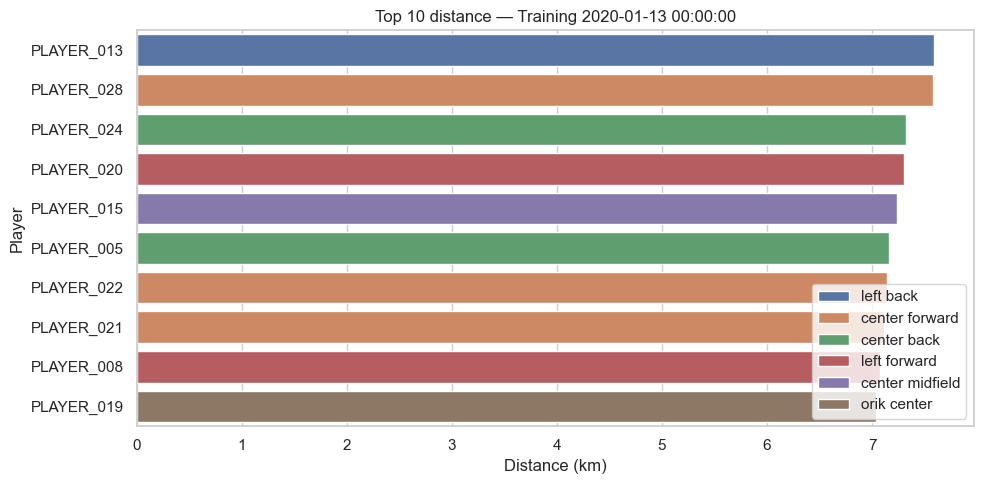

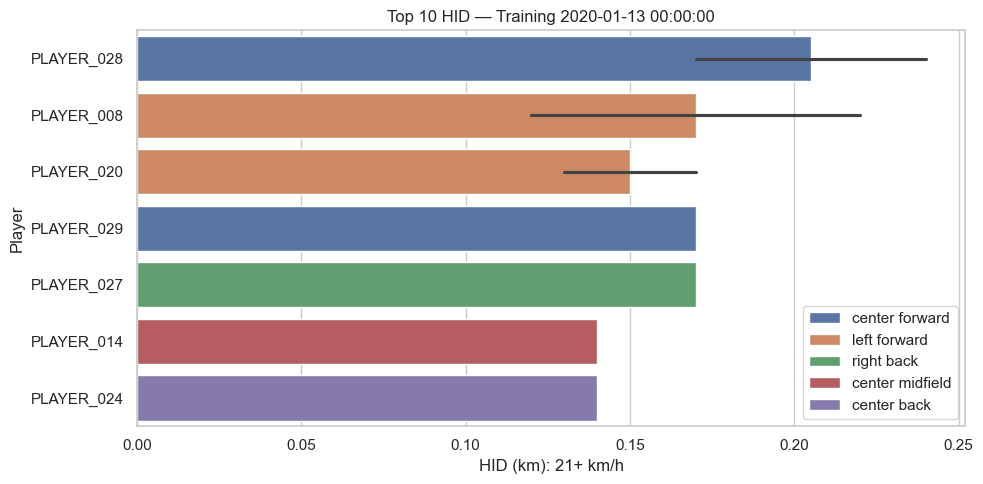

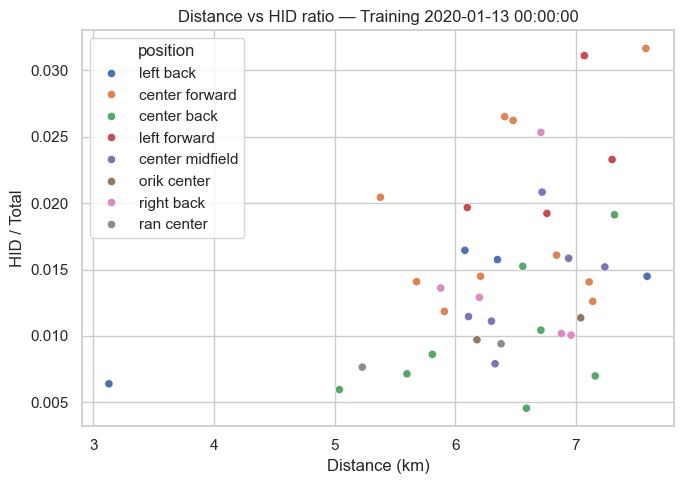

In [33]:
# ---------------------------
# 4) TRAINING — SPECIFIC SESSION (auto)
# ---------------------------

best_practice = con.execute("""
WITH per_sess AS (
  SELECT
    date_trunc('day', session_ts)::DATE AS session_date,
    COUNT(DISTINCT sensor) AS n_players,
    SUM(distance_km) AS team_distance_km,
    SUM(coalesce(d_21_24_km,0) + coalesce(d_24_30_km,0) + coalesce(d_over30_km,0)) AS team_hid_km
  FROM summary_clean
WHERE session_type='practice'
  AND distance_km IS NOT NULL
  AND distance_km >= ?
  AND (max_speed_kmh IS NULL OR max_speed_kmh <= ?)
  GROUP BY 1
)
SELECT
  session_date, n_players, team_distance_km, team_hid_km,
  team_hid_km / NULLIF(team_distance_km, 0) AS team_hid_ratio
FROM per_sess
ORDER BY team_distance_km DESC NULLS LAST
LIMIT 1;
""", [PRACTICE_MIN_DISTANCE_KM, MAX_SPEED_KMH]).fetchdf()

display(best_practice)

practice_date = best_practice.loc[0, "session_date"]
print("Selected training session:", practice_date)

practice_day_players = con.execute("""
WITH s AS (
  SELECT
    date_trunc('day', session_ts)::DATE AS session_date,
    sensor,
    position,
    distance_km,
    max_speed_kmh,
    coalesce(acc_3mss, 0) AS acc_3mss,
    coalesce(dec_3mss, 0) AS dec_3mss,
    (coalesce(d_21_24_km,0) + coalesce(d_24_30_km,0) + coalesce(d_over30_km,0)) AS hid_km,
    CASE
      WHEN distance_km IS NULL OR distance_km <= 0 THEN NULL
      ELSE (coalesce(d_21_24_km,0) + coalesce(d_24_30_km,0) + coalesce(d_over30_km,0)) / distance_km
    END AS hid_ratio
  FROM summary_clean
  WHERE session_type='practice'
    AND distance_km IS NOT NULL
    AND distance_km >= ?
    AND (max_speed_kmh IS NULL OR max_speed_kmh <= ?)
)
SELECT
  s.session_date,
  s.sensor,
  p.last_name,
  p.first_name,
  s.position,
  s.distance_km,
  s.hid_km,
  s.hid_ratio,
  s.max_speed_kmh,
  s.acc_3mss,
  s.dec_3mss
FROM s
LEFT JOIN players p USING(sensor)
WHERE s.session_date = ?
ORDER BY s.distance_km DESC NULLS LAST;
""", [PRACTICE_MIN_DISTANCE_KM, MAX_SPEED_KMH, practice_date]).fetchdf()

display(practice_day_players.head(15))

top10_practice_dist = practice_day_players.sort_values("distance_km", ascending=False).head(10)
top10_practice_hid = practice_day_players.sort_values("hid_km", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_practice_dist, y="last_name", x="distance_km", hue="position", dodge=False)
plt.title(f"Top 10 distance — Training {practice_date}")
plt.xlabel("Distance (km)")
plt.ylabel("Player")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_practice_hid, y="last_name", x="hid_km", hue="position", dodge=False)
plt.title(f"Top 10 HID — Training {practice_date}")
plt.xlabel("HID (km): 21+ km/h")
plt.ylabel("Player")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=practice_day_players, x="distance_km", y="hid_ratio", hue="position")
plt.title(f"Distance vs HID ratio — Training {practice_date}")
plt.xlabel("Distance (km)")
plt.ylabel("HID / Total")
plt.tight_layout()
plt.show()

## 5) Team data — global summary (team dashboard)

### Objective
This section produces a **dashboard view** that summarizes external load across the full dataset **match vs training** at three levels:
1) **Overall by type** (game vs practice): “what a typical match looks like” vs “what a typical training session looks like”.
2) **By position + type**: check load consistency by roles.
3) **By day (team load)**: track team load day by day and compare game/practice trends.

---

## A) Building the “player–session” dataset (`team_rows`)
From `summary_clean`, the code extracts a **player–day** table with:
- `session_date` (day), `session_type` (game/practice), `sensor`, `position`
- `distance_km`, `max_speed_kmh`, `acc_3mss`, `dec_3mss`
- `zones_sum_km`: sum of zone distances (0–5, 5–10, …, >30)  
  → useful as a consistency / composition check.
- `hid_km`: high-intensity distance (≥ 21 km/h), defined as:  
  `hid_km = d_21_24_km + d_24_30_km + d_over30_km`

Then it computes:
- `hid_ratio = hid_km / distance_km` (if `distance_km > 0`)  
  → **share of high intensity** in the player’s total distance for that session.

**Club interpretation**
- `team_rows` is the “clean” base for robust comparisons: each row = **one player in one session** (match or training).

---

## B) Dispersion function: IQR
The code defines `iqr(x) = Q3 − Q1` (interquartile range).

**Why it matters for staff**
- IQR describes **“typical” variability** (less sensitive to extremes than standard deviation),
- useful to judge whether sessions are homogeneous or highly dispersed.

---

## 1) Overall table by type: `kpi_by_type` (game vs practice)
Aggregation: `groupby("session_type")` on player–session rows.

The table returns:
- **sample size**: `n_rows`, `n_sensors`, `n_days`
- **distance**: mean / median / IQR of `distance_km`
- **HID**: mean / median / IQR of `hid_km`
- **relative intensity**: mean / median / IQR of `hid_ratio`
- **max speed**: mean / median / IQR of `max_speed_kmh`
- **effort density**: mean / median / IQR of `acc_3mss` and `dec_3mss`

**Club reading (important)**
- These stats are at the **player–session** level: “a typical player in a match” vs “a typical player in training”.
- `mean_hid_ratio` is the **mean of individual ratios**, not the team HID share. (The team HID share is computed later via `team_hid_ratio`.)

---

## 2) Table by position + type: `kpi_by_type_position`
Aggregation: `groupby(["session_type","position"])`.

The table outputs (per position):
- volume: mean/median/IQR of `distance_km`
- intensity: mean/median/IQR of `hid_ratio`
- speed exposure: mean/median/IQR of `max_speed_kmh`
- plus counters (`n_rows`, `n_sensors`)

Sorting: by `session_type`, then by `median_distance_km` descending.

**Club interpretation**
- checks role consistency: some positions should be more exposed to high speed (hid_ratio / vmax).
- IQR highlights **highly variable** positions (fluctuating load) vs **stable** ones.

---

## 3) Team-by-day summary: `team_by_day` (team load)
Aggregation: `groupby(["session_type","session_date"])` with:
- `n_players`: number of players present
- `team_distance_km`: distance sum (team volume)
- `team_hid_km`: HID sum (team fast-running volume)
- `team_acc_3mss`, `team_dec_3mss`: team sums (density)
- `avg_player_max_speed`: mean of individual vmax (global exposure)
- `max_player_max_speed`: vmax of the day (peak exposure)

Then compute:
- `team_hid_ratio = team_hid_km / team_distance_km`

Finally, the code displays:
- Top 5 **match** days by `team_distance_km`
- Top 5 **training** days by `team_distance_km`

**Club reading**
- `team_distance_km` and `team_hid_km` describe the **collective** load of the day.
- `team_hid_ratio` gives the **fast-running share** at team level (more faithful to “session content” than the mean of individual ratios).
- `n_players` is essential: a large team sum can come from a larger squad size.

---

## Mini visual dashboard (charts)
1) Boxplot `distance_km` by `session_type` (player–session)  
   → compares the distribution of individual volume match vs training.

2) Boxplot `hid_ratio` by `session_type` (player–session)  
   → compares the distribution of individual relative intensity match vs training.

3) Line chart `team_distance_km` over `session_date`, split by `session_type`  
   → tracks team volume over time and visualizes game/practice differences.

4) Line chart `team_hid_ratio` over `session_date`, split by `session_type`  
   → tracks the evolution of collective fast-running content (≥ 21 km/h) over time.

---

## Points of attention (for correct interpretation)
- `kpi_by_type` and `kpi_by_type_position` are **player–session**: they describe a typical player load, not the collective load.
- Collective load is in `team_by_day` (team sums) and depends strongly on `n_players`.
- Two “HID ratios” coexist and do not mean the same thing:
  - `hid_ratio` (player): player’s HID share.
  - `team_hid_ratio` (team): team HID share (total HID / total distance).
- This summary is an **external load** view (distance, speed, acc/dec). It does not replace internal load (RPE, HR, etc.) if the club has it.

Rows: 3988
Date range: 2019-07-04 00:00:00 → 2021-01-15 00:00:00


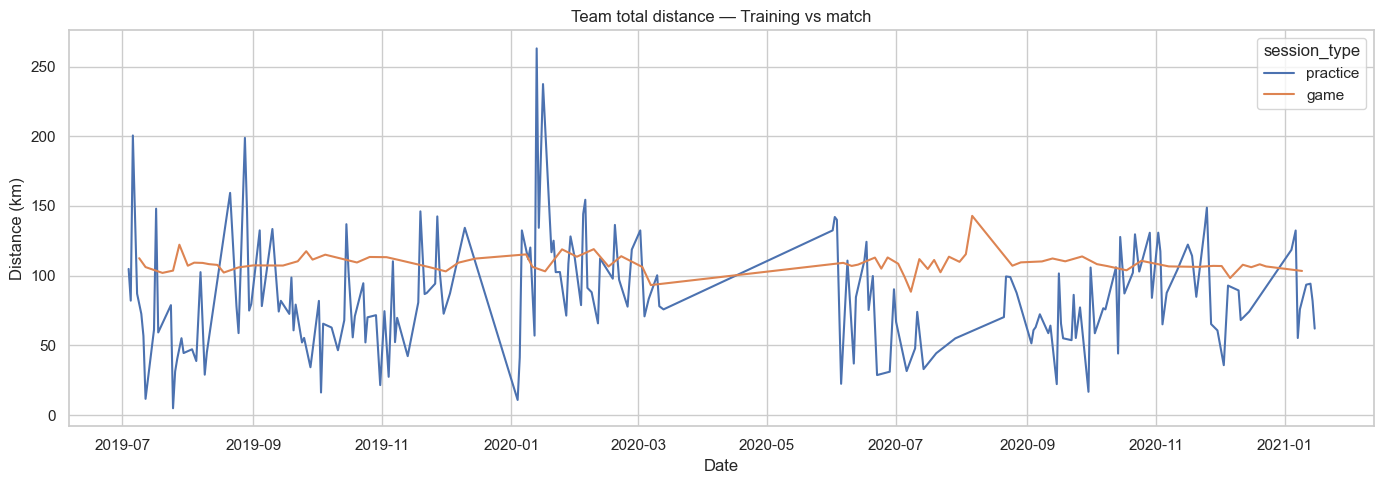

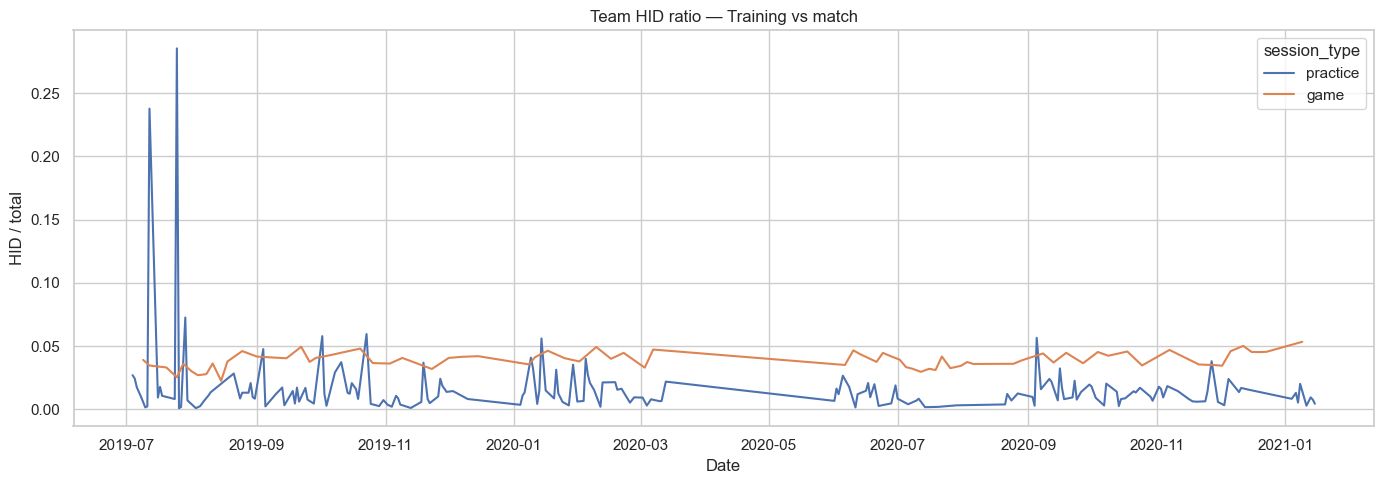

,sensor,last_name,first_name,total_distance_km,total_hid_km,mean_max_speed,n_sessions
4,4,PLAYER_005,,1426.36,25.16,24.667824,208
9,9,PLAYER_010,,1360.12,32.86,24.934381,218
5,5,PLAYER_006,,1347.86,21.25,25.123562,212
14,14,PLAYER_015,,1345.42,21.74,24.566368,186
12,12,PLAYER_013,,1335.06,35.69,26.658971,200
7,7,PLAYER_008,,1273.93,53.00,27.723333,202
11,11,PLAYER_012,,1173.94,46.41,27.078118,180
15,15,PLAYER_016,,1167.34,29.97,25.859774,169
10,10,PLAYER_011,,1135.27,24.28,25.531000,184
28,77,PLAYER_029,,1125.25,35.43,27.287742,182


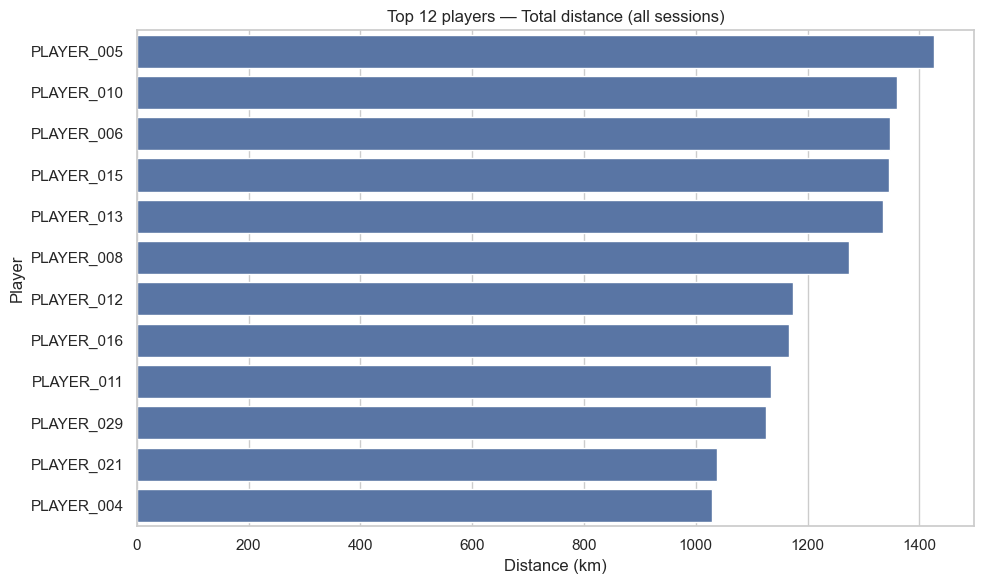

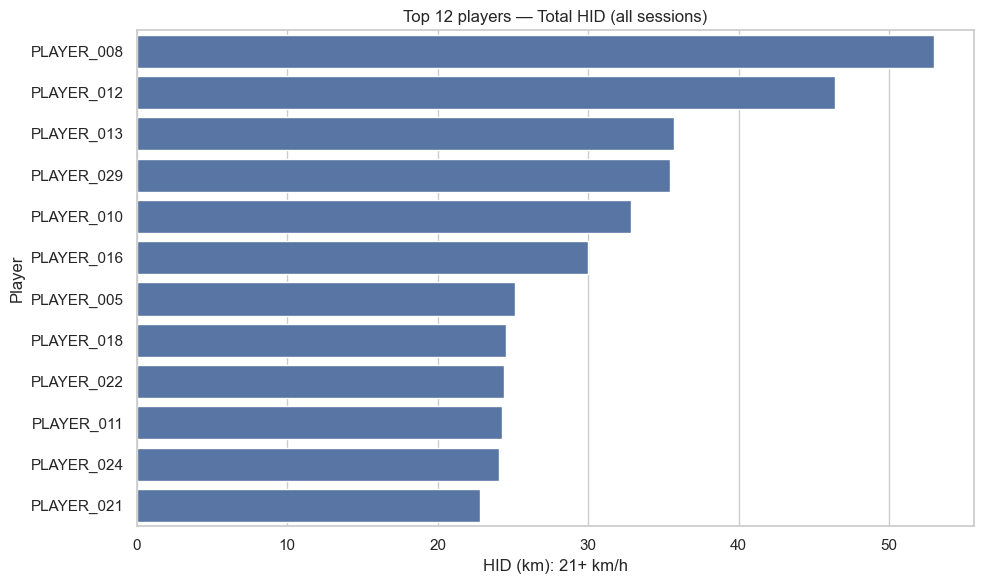

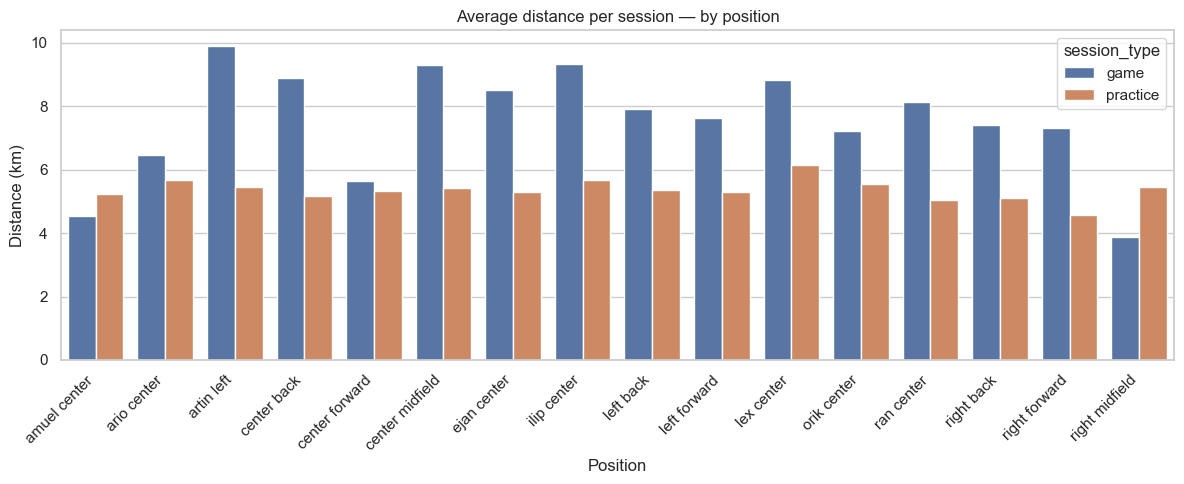

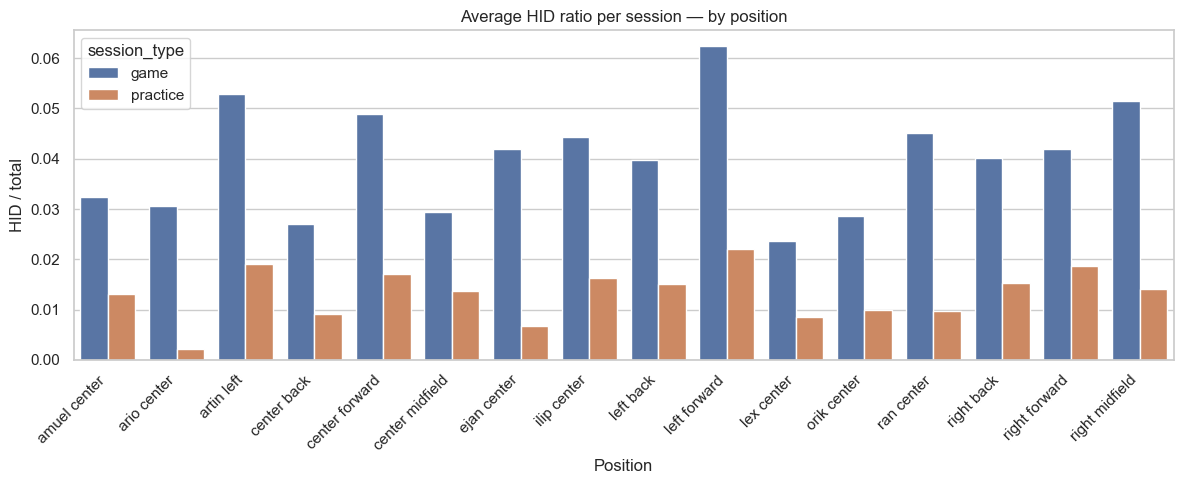

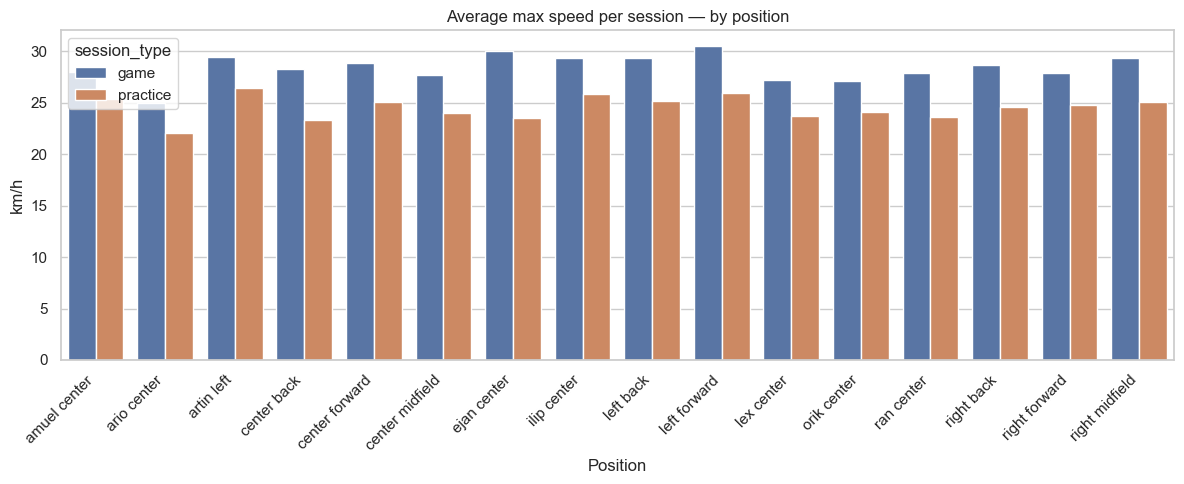

In [34]:
# ---------------------------
# 5) DASHBOARD (simple)
# ---------------------------

# Build a unified table of all sessions (practice + match) at player level
all_players = con.execute("""
SELECT
  date_trunc('day', session_ts)::DATE AS session_date,
  session_type,
  sensor,
  position,
  distance_km,
  max_speed_kmh,
  coalesce(acc_3mss, 0) AS acc_3mss,
  coalesce(dec_3mss, 0) AS dec_3mss,
  coalesce(d_0_5_km, 0) AS d_0_5_km,
  coalesce(d_5_10_km, 0) AS d_5_10_km,
  coalesce(d_10_15_km, 0) AS d_10_15_km,
  coalesce(d_15_21_km, 0) AS d_15_21_km,
  coalesce(d_21_24_km, 0) AS d_21_24_km,
  coalesce(d_24_30_km, 0) AS d_24_30_km,
  coalesce(d_over30_km, 0) AS d_over30_km
FROM summary_clean
WHERE distance_km IS NOT NULL
  AND (max_speed_kmh IS NULL OR max_speed_kmh <= ?);
""", [MAX_SPEED_KMH]).fetchdf()

# HID
all_players["hid_km"] = all_players["d_21_24_km"] + all_players["d_24_30_km"] + all_players["d_over30_km"]
all_players["hid_ratio"] = np.where(all_players["distance_km"] > 0, all_players["hid_km"] / all_players["distance_km"], np.nan)

# Attach names
players_df = con.execute("SELECT * FROM players").fetchdf()
all_players = all_players.merge(players_df, on="sensor", how="left")

all_players["session_date"] = pd.to_datetime(all_players["session_date"])

print("Rows:", len(all_players))
print("Date range:", all_players["session_date"].min(), "→", all_players["session_date"].max())

# ---------------------------
# A) Team timeline (distance + HID ratio)
# ---------------------------
team_day = (
    all_players
    .groupby(["session_date", "session_type"], as_index=False)
    .agg(
        n_players=("sensor", "nunique"),
        team_distance_km=("distance_km", "sum"),
        team_hid_km=("hid_km", "sum"),
        team_acc=("acc_3mss", "sum"),
        team_dec=("dec_3mss", "sum"),
        max_speed_session=("max_speed_kmh", "max"),
    )
)
team_day["team_hid_ratio"] = team_day["team_hid_km"] / team_day["team_distance_km"].replace({0: np.nan})

plt.figure(figsize=(14, 5))
sns.lineplot(data=team_day, x="session_date", y="team_distance_km", hue="session_type")
plt.title("Team total distance — Training vs match")
plt.xlabel("Date")
plt.ylabel("Distance (km)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
sns.lineplot(data=team_day, x="session_date", y="team_hid_ratio", hue="session_type")
plt.title("Team HID ratio — Training vs match")
plt.xlabel("Date")
plt.ylabel("HID / total")
plt.tight_layout()
plt.show()

# ---------------------------
# B) Top players — cumulative distance / HID
# ---------------------------
players_tot = (
    all_players
    .groupby(["sensor", "last_name", "first_name"], as_index=False)
    .agg(
        total_distance_km=("distance_km", "sum"),
        total_hid_km=("hid_km", "sum"),
        mean_max_speed=("max_speed_kmh", "mean"),
        n_sessions=("session_date", "nunique"),
    )
)

players_tot = players_tot.sort_values("total_distance_km", ascending=False)
display(players_tot.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=players_tot.head(12), y="last_name", x="total_distance_km")
plt.title("Top 12 players — Total distance (all sessions)")
plt.xlabel("Distance (km)")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

players_tot = players_tot.sort_values("total_hid_km", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=players_tot.head(12), y="last_name", x="total_hid_km")
plt.title("Top 12 players — Total HID (all sessions)")
plt.xlabel("HID (km): 21+ km/h")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

# ---------------------------
# C) Position-level patterns
# ---------------------------
pos = (
    all_players
    .groupby(["position", "session_type"], as_index=False)
    .agg(
        mean_distance_km=("distance_km", "mean"),
        mean_hid_ratio=("hid_ratio", "mean"),
        mean_acc=("acc_3mss", "mean"),
        mean_dec=("dec_3mss", "mean"),
        mean_max_speed=("max_speed_kmh", "mean"),
    )
)

plt.figure(figsize=(12, 5))
sns.barplot(data=pos, x="position", y="mean_distance_km", hue="session_type")
plt.title("Average distance per session — by position")
plt.xlabel("Position")
plt.ylabel("Distance (km)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=pos, x="position", y="mean_hid_ratio", hue="session_type")
plt.title("Average HID ratio per session — by position")
plt.xlabel("Position")
plt.ylabel("HID / total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=pos, x="position", y="mean_max_speed", hue="session_type")
plt.title("Average max speed per session — by position")
plt.xlabel("Position")
plt.ylabel("km/h")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6) Individual analysis — comparing two players (same role)

### Objective
This section aims to **compare two players playing the same position** over the available period to identify differences in athletic profile and effort behavior. The analysis combines:
- a **raw-values** reading (peaks, volumes, speed distribution);
- a **relative** reading via **player-normalized KPIs**, i.e., interpreted against each player’s usual variability (and separately for match vs training).

---

### Parameters (reproducible for the club)
- **`MIN_SESSIONS`**: minimum number of sessions per player to be eligible for comparison.  
  Purpose: avoid conclusions based on too small a sample.

- **`TARGET_POSITION`**: target position, normalized as **uppercase + trimmed** (`upper(trim(...))`).  
  Note: positions are text in the data (e.g., *CENTER BACK*, *RIGHT BACK*, *CENTER MIDFIELD*). If the provided position does not exist or does not have enough eligible players, the code automatically falls back to the most represented eligible position.

- **`SENSOR_A` / `SENSOR_B`**: identifiers of the two players (sensors).  
  If not provided, the code automatically selects the **two players in the position** with the highest number of sessions (more robust comparison).

---

### Identifying eligible positions
The code first builds a `pos_eligible` table:
1) count sessions per **sensor × position**;
2) filter on `n_sessions >= MIN_SESSIONS`;
3) aggregate by position to get:
   - number of eligible players,
   - min / mean / max sessions available.

This table is a **quality control** (ensure at least two players are comparable in a position with sufficient data). If no position is eligible, the only consistent action is to reduce `MIN_SESSIONS`.

---

### Selecting the two players within the same position
The `cand_role` table lists, for the chosen position:
- total `n_sessions`,
- `n_game` and `n_practice` (match/training split).

The goal is twofold:
- ensure **both players belong to the same role**;
- make selection traceable (table is displayed) and controllable (manual selection possible).

A labeling function `plabel()` is used to display a readable label (last/first name when available, otherwise the sensor).

---

### Building the session-by-session dataset (KPIs)
For the two selected sensors, the query extracts from `summary_clean`:
- **context**: session date, session type (*game* / *practice*), position;
- **external load**: `distance_km`;
- **intensity/peaks**: `avg_speed_kmh`, `max_speed_kmh`, `max_acc_ms2`;
- **high efforts**: `acc_3mss` and `dec_3mss` (accelerations/decelerations ≥ 3 m/s²);
- **speed distribution**: distances by zones (0–5, 5–10, …, >30 km/h).

From these variables, three derived indicators are computed:

1) **HID (High-Intensity Distance)**  
\[
$\text{hid\_km} = d_{21-24} + d_{24-30} + d_{>30}$
\]
And the **HID ratio**:
\[
$\text{hid\_ratio} = \frac{\text{hid\_km}}{\text{distance\_km}}$
\]
Interpretation: distinguishes **total volume** from **relative intensity share**.

2) **Effort density**  
\[
$\text{accdec\_total} = \text{acc\_3mss} + \text{dec\_3mss}$
\]
\[
$\text{accdec\_per\_km} = \frac{\text{accdec\_total}}{\text{distance\_km}}$
\]
Interpretation: measures “stop-and-go / pace changes” **normalized per km**, useful to compare profiles without relying only on sprints.

---

### Profile 1 — Acceleration ↔ speed relationship (per session)
A scatter plot compares:
- x-axis: `max_speed_kmh`
- y-axis: `max_acc_ms2`
- color: player
- style: session type (match vs training)

Purpose: place each player on a “ability to reach speed peaks” vs “ability to produce acceleration peaks” axis, while observing differences between match and training contexts.

---

### Profile 2 — Speed distribution (zone shares)
For each session, the share of distance in each zone is computed:
\[
$\text{share}_{zone} = \frac{d_{zone}}{\text{distance\_km}}$
\]
Then these shares are averaged by player and session type. The produced charts allow:
- a global comparison (mean over all sessions),
- then a **separated** comparison match vs training (different intensity contexts).

Purpose: characterize a “low-intensity volume” player vs a “high-intensity volume” player, independently of total distance.

---

### Profile 3 — Effort density (accelerations + decelerations per km)
A boxplot compares `accdec_per_km`:
- between match and training,
- between the two players.

A summary table also provides medians (by session type) and the number of sessions contributing to the calculation.  
Purpose: highlight a more “intermittent / pace-change” profile vs a more “linear” one, and check whether the gap increases in matches.

---

### Player-normalized KPIs (z-scores) and heatmaps
To avoid comparing only raw values (often dependent on exact role, minutes played, context), the code computes **z-scores per player and per session type**:

\[
$z = \frac{x - \mu}{\sigma}$
\]

- Computed separately for *game* and *practice*: avoids mixing naturally different distributions.
- Z-scores are then summarized (median) per player and displayed as a **heatmap**.

Interpretation:
- a positive z-score indicates a value **above** the player’s usual level in that context;
- a negative z-score indicates a value **below**;
- the heatmap quickly shows on which dimensions each player stands out relative to their own norm (distance, intensity, acc/dec, effort density, etc.).

,sensor,last_name,first_name,n_sessions
9,9,PLAYER_010,,218
5,5,PLAYER_006,,212
4,4,PLAYER_005,,208
7,7,PLAYER_008,,202
12,12,PLAYER_013,,200
20,20,PLAYER_021,,197
14,14,PLAYER_015,,186
10,10,PLAYER_011,,184
28,77,PLAYER_029,,182
11,11,PLAYER_012,,180


Selected players:
- Player 1: 9 PLAYER_010
- Player 2: 5 PLAYER_006


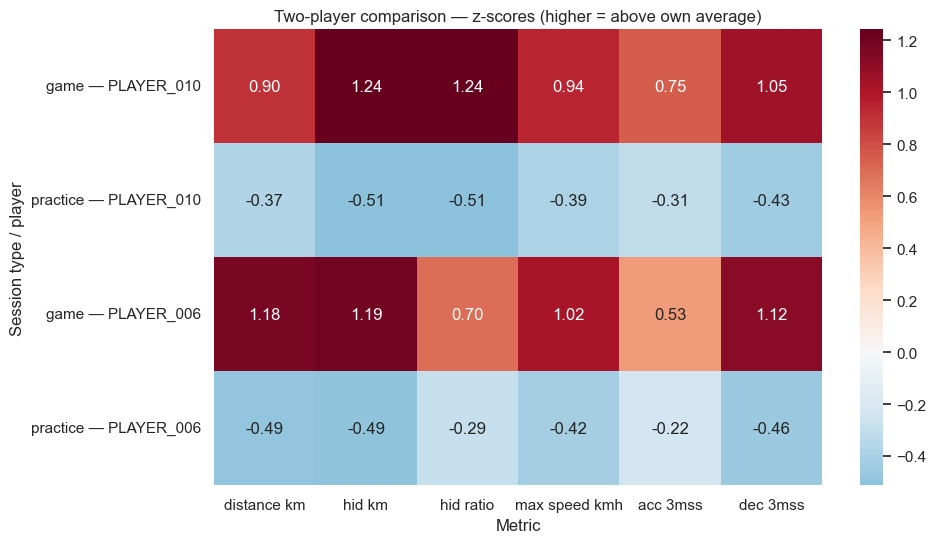

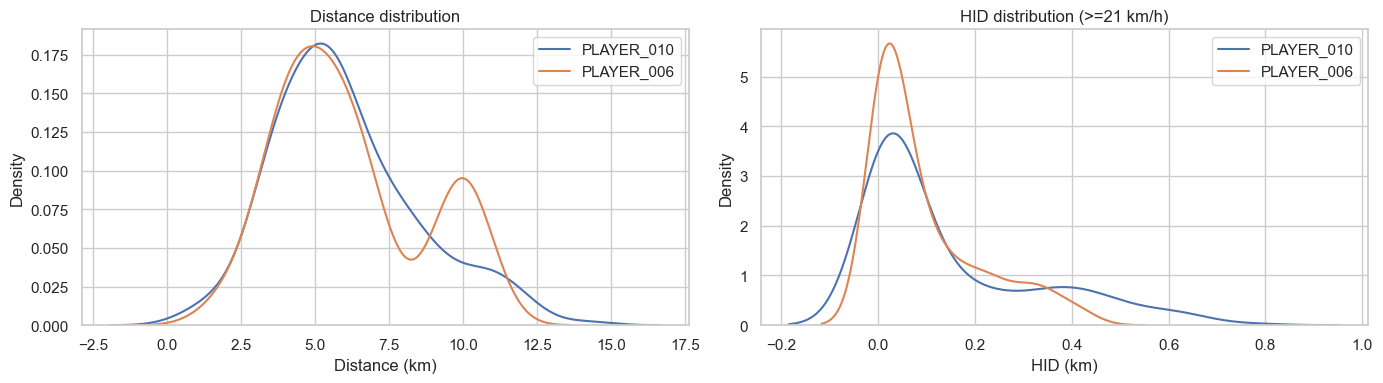

In [35]:
# ---------------------------
# 6) TWO-PLAYER COMPARISON (auto)
# ---------------------------

# Idea: pick two players with enough sessions, then compare z-scores across metrics.

# Build per-player per-session table
cmp = con.execute("""
SELECT
  date_trunc('day', session_ts)::DATE AS session_date,
  session_type,
  sensor,
  position,
  distance_km,
  max_speed_kmh,
  coalesce(acc_3mss, 0) AS acc_3mss,
  coalesce(dec_3mss, 0) AS dec_3mss,
  (coalesce(d_21_24_km,0) + coalesce(d_24_30_km,0) + coalesce(d_over30_km,0)) AS hid_km
FROM summary_clean
WHERE distance_km IS NOT NULL
  AND (max_speed_kmh IS NULL OR max_speed_kmh <= ?);
""", [MAX_SPEED_KMH]).fetchdf()

cmp["hid_ratio"] = np.where(cmp["distance_km"] > 0, cmp["hid_km"] / cmp["distance_km"], np.nan)

# Attach names
players_df = con.execute("SELECT * FROM players").fetchdf()
cmp = cmp.merge(players_df, on="sensor", how="left")

cmp["session_date"] = pd.to_datetime(cmp["session_date"])

# Keep players with enough sessions
min_sessions = 15
counts = cmp.groupby(["sensor", "last_name", "first_name"], as_index=False).agg(n_sessions=("session_date", "nunique"))
eligible = counts[counts["n_sessions"] >= min_sessions].sort_values("n_sessions", ascending=False)

display(eligible.head(10))

if len(eligible) < 2:
    print(f"Not enough players with >= {min_sessions} sessions.")
else:
    p1 = eligible.iloc[0]["sensor"]
    p2 = eligible.iloc[1]["sensor"]

    p1_name = f"{eligible.iloc[0]['last_name']} {eligible.iloc[0]['first_name']}".strip()
    p2_name = f"{eligible.iloc[1]['last_name']} {eligible.iloc[1]['first_name']}".strip()

    print("Selected players:")
    print("- Player 1:", p1, p1_name)
    print("- Player 2:", p2, p2_name)

    metrics = ["distance_km", "hid_km", "hid_ratio", "max_speed_kmh", "acc_3mss", "dec_3mss"]

    def zscore(series: pd.Series) -> pd.Series:
        s = series.astype(float)
        mu = s.mean(skipna=True)
        sd = s.std(skipna=True)
        if sd == 0 or np.isnan(sd):
            return (s - mu) * 0.0
        return (s - mu) / sd

    df_p1 = cmp[cmp["sensor"] == p1].copy()
    df_p2 = cmp[cmp["sensor"] == p2].copy()

    # Z-score within each player's history
    for m in metrics:
        df_p1[m + "_z"] = zscore(df_p1[m])
        df_p2[m + "_z"] = zscore(df_p2[m])

    # Aggregate by session_type for a compact comparison
    agg_p1 = df_p1.groupby("session_type")[ [m + "_z" for m in metrics] ].mean().rename(index=lambda x: f"{x} — {p1_name}")
    agg_p2 = df_p2.groupby("session_type")[ [m + "_z" for m in metrics] ].mean().rename(index=lambda x: f"{x} — {p2_name}")

    heat = pd.concat([agg_p1, agg_p2], axis=0)
    heat.columns = [m.replace("_", " ") for m in metrics]

    plt.figure(figsize=(10, 4 + 0.4*len(heat)))
    sns.heatmap(heat, annot=True, center=0, cmap="RdBu_r", fmt=".2f")
    plt.title("Two-player comparison — z-scores (higher = above own average)")
    plt.xlabel("Metric")
    plt.ylabel("Session type / player")
    plt.tight_layout()
    plt.show()

    # Quick distribution view for distance and HID (raw values)
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    sns.kdeplot(data=df_p1, x="distance_km", label=p1_name, ax=ax[0])
    sns.kdeplot(data=df_p2, x="distance_km", label=p2_name, ax=ax[0])
    ax[0].set_title("Distance distribution")
    ax[0].set_xlabel("Distance (km)")
    ax[0].legend()

    sns.kdeplot(data=df_p1, x="hid_km", label=p1_name, ax=ax[1])
    sns.kdeplot(data=df_p2, x="hid_km", label=p2_name, ax=ax[1])
    ax[1].set_title("HID distribution (>=21 km/h)")
    ax[1].set_xlabel("HID (km)")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

## Overall conclusion

This project built a performance monitoring tool usable in a club context from GPS/IMU data, with a production-oriented approach: session centralization, KPI standardization, and data quality control before any interpretation. Using DuckDB and a cleaned view (`summary_clean`) provides a robust, reproducible foundation to query history in SQL and generate consistent outputs (tables and charts) for the staff.

From an analytical standpoint, the notebook highlights the necessary complementarity between **volume** (total distance), **intensity** (HID and HID ratio), **speed exposure** (max speeds, zones), and **effort density** (accelerations/decelerations). The structured match vs training comparison, plus per-player KPIs and variability measures (percentiles, CV), helps position training load relative to match demands and assess planning stability. Finally, the individual component (two players in the same position) illustrates the value of normalized reading (z-scores): it places performances in each player’s usual reference frame and limits conclusions biased by context differences.

Results should still be interpreted cautiously: analyses rely on aggregated “player–session” KPIs and do not describe within-session dynamics (phases, repeated sequences), which would require full raw tracking exploitation. Squad size also strongly influences collective aggregations, and external load does not replace internal load if available (RPE, heart rate). Under these conditions, this notebook provides a solid base for regular, comparable load monitoring and naturally opens to extensions: integrating raw tracking for temporal analyses and enriching with internal indicators for a more complete view of risk and recovery.